# ED²A - Explainable Differential Diagnosis Assistant
## Exploratory Data Analysis and Multiclass Modelling on DDXPlus Dataset

**Course:** DATA SCIENCE FOR BUSINESS
**Author:** Alessandro Bulgheroni - 716653
**Dataset:** DDXPlus  
**Target:** `PATHOLOGY` (Classification on 49 class single labelled)  
**Runtime predictors:** `AGE`, `SEX`, `EVIDENCES` and `INITIAL_EVIDENCE`  
**Experimental split:** 70% training, 20% validation and 10% test 
**Compared training strategies:** FLAML AutoML and a standalone weighted XGBoost classifier

The notebook studies a large synthetic telemedicine dataset, describes its main statistical properties, defines a leakage-aware preprocessing pipeline and compares two tree-ensemble strategies under the same holdout protocol. Model selection is based on validation macro F1; the test partition is reserved for the final generalisation assessment.

The selected estimator, preprocessing pipeline and label order are exported for the ED²A FastAPI application.

## Table of contents

1. Research objective and experimental design
2. Environment and reproducibility
3. Dataset discovery and loading
4. Data audit and cleaning
5. Exploratory Data Analysis
6. Feature engineering and leakage control
7. Stratified split and training-only data augmentation
8. Class-imbalance handling
9. FLAML AutoML
10. Standalone XGBoost
11. Validation-based model selection
12. Final test evaluation
13. Explainability and generalisation diagnostics
14. Model export and API compatibility
15. Conclusions, limitations and references

## 1. Research objective and experimental design

The objective is to predict the most likely pathology using information collected during a telemedicine intake. The following analysis choices were made:

| Component | Design choice |
|---|---|
| Prediction task | Single-label multiclass classification |
| Target | `PATHOLOGY` |
| Input representation | Age, sex, complete evidence tokens and initial evidence |
| Holdout protocol | Stratified 70/20/10 training/validation/test split |
| Training-only augmentation | Conservative masking of one secondary evidence for selected minority-class cases |
| Compared strategies | FLAML over XGBoost, Random Forest and Extra Trees; standalone weighted XGBoost |
| Selection criterion | Validation macro F1, with macro ROC AUC and accuracy as tie-breakers |
| Final assessment | Accuracy, balanced accuracy, precision, sensitivity, specificity, F1, log loss, top-k accuracy, ROC/AUC and confusion matrices on the untouched test set |

Macro-averaged metrics are central because DDXPlus is strongly imbalanced: each pathology must contribute equally to the summary score, regardless of its prevalence.

### 1.1 Problem formulation and leakage boundary

DDXPlus contains synthetic patient profiles generated from a medical knowledge base. Each row includes socio-demographic variables, observed evidences, a ground-truth pathology and a reference differential diagnosis.

| Field | Role | Available at inference time |
|---|---|---|
| `AGE` | Numerical predictor | Yes |
| `SEX` | Nominal predictor | Yes |
| `EVIDENCES` | List of binary or valued evidence tokens | Yes |
| `INITIAL_EVIDENCE` | Nominal predictor | Yes, but optional |
| `PATHOLOGY` | Ground-truth class | No |
| `DIFFERENTIAL_DIAGNOSIS` | Reference differential and probabilities | No |

`PATHOLOGY` and `DIFFERENTIAL_DIAGNOSIS` are excluded from the predictors. The latter contains diagnostic information that would not be available to the deployed model and would therefore cause target leakage. Although the API returns a ranked top-k differential, training remains a single-label multiclass problem because every row has one ground-truth pathology.

## 2. Environment and reproducibility

The notebook is designed for Kaggle and pins the versions used by the FastAPI runtime so that the exported `joblib` objects can be loaded consistently. A fixed random seed controls the explicit data split and the custom augmentation procedure. GPU availability is detected at runtime, with a CPU fallback for XGBoost.

The saved configuration uses:

- at most **100 FLAML search trials**, with FLAML's native convergence-based early stopping;
- at most **100 XGBoost boosting rounds**;
- **20 validation rounds** of XGBoost early-stopping patience.

These are search trials and boosting rounds, not neural-network epochs.

In [ ]:
# Setup di Kaggle
# TPOT si può disinstallare perchè a volte ci sono degli errori strani dovuti al componente

%pip uninstall -y TPOT
%pip install -q --upgrade \
    "flaml[automl]>=2.3,<3" \
    "scikit-learn==1.6.1" \
    "xgboost==2.1.4" \
    "joblib==1.5.3"

Found existing installation: TPOT 1.1.0
Uninstalling TPOT-1.1.0:
  Successfully uninstalled TPOT-1.1.0
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 2.9 MB/s eta 0:00:0000:0100:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 11.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import ast
import copy
import gc
import json
import platform
import shutil
import subprocess
import time
import warnings
from collections import Counter
from datetime import datetime, timezone
from itertools import chain
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from IPython.display import FileLink, Markdown, display
from scipy import sparse
from scipy.stats import median_abs_deviation, trim_mean

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    auc,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    top_k_accuracy_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Gestisco QUICK_RUN per fare i test ed evitare ore di training
QUICK_RUN = False
QUICK_RUN_ROWS_PER_FILE = 20_000

# Experimental budgets and training-only augmentation controls.
FLAML_ITERATIONS = 100
FLAML_NATIVE_EARLY_STOP = True
FLAML_AUTO_AUGMENT = False  # Augmentation custom di FLAML. Per il momento lascio a FALSE
XGBOOST_ROUNDS = 100
XGBOOST_EARLY_STOPPING_ROUNDS = 20
AUGMENTATION_TARGET_QUANTILE = 0.25
AUGMENTATION_MAX_PER_CLASS = 2_000
N_JOBS = -1

PALETTE = {
    "navy": "#16324F",
    "blue": "#247BA0",
    "teal": "#2A9D8F",
    "gold": "#E9C46A",
    "orange": "#F4A261",
    "red": "#E76F51",
    "grey": "#6B7280",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "figure.titlesize": 15,
})


def gpu_is_available() -> bool:
    try:
        result = subprocess.run(
            ["nvidia-smi"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False
        )
        return result.returncode == 0
    except FileNotFoundError:
        return False


GPU_AVAILABLE = gpu_is_available()
XGB_DEVICE = "cuda" if GPU_AVAILABLE else "cpu"

environment = pd.DataFrame(
    {
        "Component": ["Python", "NumPy", "pandas", "scikit-learn", "XGBoost", "joblib", "GPU"],
        "Version / status": [
            platform.python_version(),
            np.__version__,
            pd.__version__,
            sklearn.__version__,
            xgboost.__version__,
            joblib.__version__,
            f"available ({XGB_DEVICE})" if GPU_AVAILABLE else "not available (CPU fallback)",
        ],
    }
)
display(environment)
print(f"QUICK_RUN={QUICK_RUN}; random_state={RANDOM_STATE}")
print(
    f"Budgets: FLAML <= {FLAML_ITERATIONS} AutoML search trials "
    f"(native early_stop={FLAML_NATIVE_EARLY_STOP}); "
    f"XGBoost <= {XGBOOST_ROUNDS} boosting rounds "
    f"(early-stopping patience {XGBOOST_EARLY_STOPPING_ROUNDS} validation rounds)"
)

,Component,Version / status
0,Python,3.12.13
1,NumPy,2.0.2
2,pandas,2.3.3
3,scikit-learn,1.6.1
4,XGBoost,2.1.4
5,joblib,1.5.3
6,GPU,available (cuda)


QUICK_RUN=False; random_state=42
Budgets: FLAML <= 100 AutoML search trials (native early_stop=True); XGBoost <= 100 boosting rounds (early-stopping patience 20 validation rounds)


## 3. Dataset discovery and loading

The data source is [DDXPlus English v2](https://www.kaggle.com/datasets/deveddu17xx/ddxplus-english-v2). The resolver accepts both the official `release_*_patients.csv` filenames and the shorter `train.csv`, `validate.csv` and `test.csv` aliases.

All available patient files are loaded with a common schema and combined before constructing the study-specific 70/20/10 split. The original filename is retained only for the source manifest and is never used as a predictor. The saved execution contains **1,292,579 patient rows**.

In [3]:
CSV_ALIASES = {
    "train": ["release_train_patients.csv", "train.csv"],
    "validate": ["release_validate_patients.csv", "validate.csv", "validation.csv", "val.csv"],
    "test": ["release_test_patients.csv", "test.csv"],
}
JSON_ALIASES = {
    "evidences": ["release_evidences.json"],
    "conditions": ["release_conditions.json"],
}


def candidate_roots() -> list[Path]:
    roots = [
        Path("/kaggle/input/ddxplus-english-v2"),
        Path("/kaggle/input"),
        Path.cwd(),
        Path.cwd() / "data",
        Path.cwd() / "data" / "raw",
    ]
    return [root for root in roots if root.exists()]


def resolve_first(names: list[str]) -> Path | None:
    roots = candidate_roots()
    for root in roots:
        for name in names:
            direct = root / name
            if direct.is_file():
                return direct
    for root in roots:
        for name in names:
            matches = sorted(root.rglob(name))
            if matches:
                return matches[0]
    return None


csv_paths = {split: resolve_first(names) for split, names in CSV_ALIASES.items()}
csv_paths = {split: path for split, path in csv_paths.items() if path is not None}
metadata_paths = {name: resolve_first(names) for name, names in JSON_ALIASES.items()}

if not csv_paths:
    raise FileNotFoundError(
        "No DDXPlus patient CSV was found. On Kaggle, attach dataset "
        "'deveddu17xx/ddxplus-english-v2' to this notebook."
    )

resolved_files = pd.DataFrame(
    [
        {"logical_name": split, "path": str(path), "size_mb": path.stat().st_size / 2**20}
        for split, path in csv_paths.items()
    ]
    + [
        {
            "logical_name": name,
            "path": str(path) if path else "not found (optional for modelling)",
            "size_mb": path.stat().st_size / 2**20 if path else np.nan,
        }
        for name, path in metadata_paths.items()
    ]
)
display(resolved_files.style.format({"size_mb": "{:.2f}"}, na_rep="-"))

,logical_name,path,size_mb
0,train,/kaggle/input/datasets/deveddu17xx/ddxplus-english-v2/release_train_patients.csv,639.52
1,validate,/kaggle/input/datasets/deveddu17xx/ddxplus-english-v2/release_validate_patients.csv,83.32
2,test,/kaggle/input/datasets/deveddu17xx/ddxplus-english-v2/release_test_patients.csv,84.48
3,evidences,/kaggle/input/datasets/deveddu17xx/ddxplus-english-v2/release_evidences.json,0.11
4,conditions,/kaggle/input/datasets/deveddu17xx/ddxplus-english-v2/release_conditions.json,0.02


In [4]:
MODEL_COLUMNS = ["AGE", "SEX", "PATHOLOGY", "EVIDENCES", "INITIAL_EVIDENCE"]
def read_patient_file(path: Path, source_name: str) -> tuple[pd.DataFrame, list[str]]:
    header = pd.read_csv(path, nrows=0).columns.tolist()
    missing = set(MODEL_COLUMNS) - set(header)
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {sorted(missing)}")

    kwargs = {
        "usecols": MODEL_COLUMNS,
        "nrows": QUICK_RUN_ROWS_PER_FILE if QUICK_RUN else None,
        "low_memory": False,
    }
    try:
        frame = pd.read_csv(path, **kwargs)
    except pd.errors.ParserError as exc:
        # This fallback also tolerates an incomplete final record in a locally copied CSV.
        print(f"C-parser warning for {path.name}: {exc}")
        print("Retrying with the Python parser and skipping malformed records.")
        frame = pd.read_csv(
            path,
            usecols=MODEL_COLUMNS,
            nrows=QUICK_RUN_ROWS_PER_FILE if QUICK_RUN else None,
            engine="python",
            on_bad_lines="warn",
        )

    frame["SOURCE_SPLIT"] = source_name
    return frame, header


frames = []
schemas = {}
for split_name, path in csv_paths.items():
    frame, header = read_patient_file(path, split_name)
    frames.append(frame)
    schemas[split_name] = header

patients_raw = pd.concat(frames, ignore_index=True)
source_manifest = (
    patients_raw.groupby("SOURCE_SPLIT", observed=True)
    .size()
    .rename("rows")
    .to_frame()
    .assign(percent=lambda d: 100 * d["rows"] / d["rows"].sum())
)

display(source_manifest.style.format({"percent": "{:.2f}%"}))
print(f"Combined rows: {len(patients_raw):,}")
print(f"Columns loaded for analysis: {MODEL_COLUMNS}")
print("Full source schemas:")
for name, schema in schemas.items():
    print(f"  {name}: {schema}")

,rows,percent
SOURCE_SPLIT,,
test,134529,10.41%
train,1025602,79.35%
validate,132448,10.25%


Combined rows: 1,292,579
Columns loaded for analysis: ['AGE', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']
Full source schemas:
  train: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']
  validate: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']
  test: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']


## 4. Data audit and cleaning

The audit covers data types, missing values, cardinality, duplicate profiles, sex codes, age range, target coverage and evidence-list syntax. Cleaning is deliberately conservative:

- rows missing the target or a required runtime predictor are excluded;
- missing `INITIAL_EVIDENCE` values receive an explicit sentinel because the API field is optional;
- ages are converted to numeric values but are not clipped automatically;
- evidence lists are parsed with `ast.literal_eval` rather than `eval`;
- exact duplicate profiles are counted but retained, since the dataset represents independently generated synthetic patients.

The saved run found no missing ages, no invalid evidence lists and no rows requiring removal. It also identified 17,324 exact duplicates across the runtime predictors and target; their possible effect on holdout performance is discussed in the limitations.

In [ ]:
audit = pd.DataFrame(
    {
        "dtype": patients_raw[MODEL_COLUMNS].dtypes.astype(str),
        "missing_n": patients_raw[MODEL_COLUMNS].isna().sum(),
        "missing_pct": 100 * patients_raw[MODEL_COLUMNS].isna().mean(),
        "unique_n": patients_raw[MODEL_COLUMNS].nunique(dropna=False),
    }
)

# duplicate_subset = ["AGE", "SEX", "PATHOLOGY", "EVIDENCES", "INITIAL_EVIDENCE", "ANTECEDENT"]
duplicate_subset = ["AGE", "SEX", "PATHOLOGY", "EVIDENCES", "INITIAL_EVIDENCE"]
exact_duplicates = int(patients_raw.duplicated(subset=duplicate_subset).sum())

display(audit.style.format({"missing_pct": "{:.4f}%"}))
print(f"Exact duplicate rows across runtime features and target: {exact_duplicates:,}")
print(f"Observed SEX values: {sorted(patients_raw['SEX'].dropna().astype(str).unique())}")
print(
    "Observed AGE range:",
    pd.to_numeric(patients_raw["AGE"], errors="coerce").min(),
    "to",
    pd.to_numeric(patients_raw["AGE"], errors="coerce").max(),
)
print(f"Observed PATHOLOGY classes: {patients_raw['PATHOLOGY'].nunique(dropna=True)}")

,dtype,missing_n,missing_pct,unique_n
AGE,int64,0,0.0000%,110
SEX,object,0,0.0000%,2
PATHOLOGY,object,0,0.0000%,49
EVIDENCES,object,0,0.0000%,1034507
INITIAL_EVIDENCE,object,0,0.0000%,96


Exact duplicate rows across runtime features and target: 17,324
Observed SEX values: ['F', 'M']
Observed AGE range: 0 to 109
Observed PATHOLOGY classes: 49


In [6]:
def parse_evidence_list(value):
    """Safely parse a DDXPlus evidence-list cell into a list of string tokens."""
    if isinstance(value, list):
        return [str(token) for token in value]
    if pd.isna(value):
        return None
    try:
        parsed = ast.literal_eval(str(value))
    except (ValueError, SyntaxError):
        return None
    if not isinstance(parsed, (list, tuple)):
        return None
    tokens = [str(token).strip() for token in parsed if str(token).strip()]
    return tokens or None


patients = patients_raw.copy()
patients["AGE"] = pd.to_numeric(patients["AGE"], errors="coerce")
patients["SEX"] = patients["SEX"].astype("string").str.strip().str.upper()
patients["PATHOLOGY"] = patients["PATHOLOGY"].astype("string").str.strip()
patients["INITIAL_EVIDENCE"] = (
    patients["INITIAL_EVIDENCE"].astype("string").str.strip().fillna("__MISSING__")
)
patients["EVIDENCES"] = patients["EVIDENCES"].map(parse_evidence_list)

required_non_null = ["AGE", "SEX", "PATHOLOGY", "EVIDENCES"]
invalid_mask = patients[required_non_null].isna().any(axis=1)
invalid_evidence_rows = int(patients["EVIDENCES"].isna().sum())
invalid_age_rows = int(patients["AGE"].isna().sum())

print(f"Rows with unparseable/empty EVIDENCES: {invalid_evidence_rows:,}")
print(f"Rows with non-numeric/missing AGE: {invalid_age_rows:,}")
print(f"Rows removed by required-field validation: {int(invalid_mask.sum()):,}")

patients = patients.loc[~invalid_mask].reset_index(drop=True)
patients["AGE"] = patients["AGE"].astype(np.float32)
patients["N_EVIDENCES"] = patients["EVIDENCES"].map(len).astype(np.int16)

unexpected_sex_codes = sorted(set(patients["SEX"].dropna()) - {"F", "M"})
if unexpected_sex_codes:
    raise ValueError(f"Unexpected SEX codes after cleaning: {unexpected_sex_codes}")
if not patients["AGE"].between(0, 120).all():
    raise ValueError("AGE contains values outside the accepted 0–120 year range.")

assert patients["PATHOLOGY"].nunique() >= 2
assert patients["EVIDENCES"].map(lambda x: isinstance(x, list) and len(x) > 0).all()

preview = patients.head(5).copy()
preview["EVIDENCES"] = preview["EVIDENCES"].map(
    lambda values: values[:8] + (["..."] if len(values) > 8 else [])
)
display(preview)
print(f"Usable rows after validation: {len(patients):,}")

del patients_raw, frames
gc.collect()

Rows with unparseable/empty EVIDENCES: 0
Rows with non-numeric/missing AGE: 0
Rows removed by required-field validation: 0


,AGE,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE,SOURCE_SPLIT,N_EVIDENCES
0,18.0,M,URTI,"[E_48, E_50, E_53, E_54_@_V_161, E_54_@_V_183,...",E_91,train,19
1,21.0,M,HIV (initial infection),"[E_9, E_27, E_50, E_51, E_53, E_54_@_V_198, E_...",E_50,train,31
2,19.0,F,Pneumonia,"[E_53, E_54_@_V_179, E_54_@_V_192, E_55_@_V_29...",E_77,train,34
3,34.0,F,URTI,"[E_48, E_53, E_54_@_V_183, E_55_@_V_89, E_55_@...",E_53,train,16
4,36.0,M,URTI,"[E_49, E_50, E_53, E_54_@_V_183, E_55_@_V_62, ...",E_201,train,17


Usable rows after validation: 1,292,579


3870

### 4.1 Metadata integrity

The evidence and condition JSON files are used only to interpret codes, label visualisations and support the application's evidence and urgency displays. They are not included in the model matrix. In particular, condition severity is defined at pathology level and would reveal information about the target if used as a predictor.

In [7]:
evidence_metadata = {}
condition_metadata = {}

if metadata_paths.get("evidences"):
    with metadata_paths["evidences"].open("r", encoding="utf-8") as file:
        evidence_metadata = json.load(file)
if metadata_paths.get("conditions"):
    with metadata_paths["conditions"].open("r", encoding="utf-8") as file:
        condition_metadata = json.load(file)

metadata_audit = pd.DataFrame(
    {
        "metadata": ["Evidence definitions", "Condition definitions", "CSV target classes"],
        "count": [
            len(evidence_metadata) if evidence_metadata else np.nan,
            len(condition_metadata) if condition_metadata else np.nan,
            patients["PATHOLOGY"].nunique(),
        ],
    }
)
display(metadata_audit)

if condition_metadata:
    json_conditions = set(condition_metadata)
    csv_conditions = set(patients["PATHOLOGY"].dropna().astype(str).unique())
    print("Target classes missing from condition metadata:", sorted(csv_conditions - json_conditions))
    print("Condition definitions not observed in CSV target:", sorted(json_conditions - csv_conditions))

,metadata,count
0,Evidence definitions,223
1,Condition definitions,49
2,CSV target classes,49


Target classes missing from condition metadata: []
Condition definitions not observed in CSV target: []


## 5. Exploratory Data Analysis

### 5.1 Numerical distributions

Age and the number of recorded evidences are described using both classical and robust statistics: mean, trimmed mean, median, standard deviation, median absolute deviation, percentiles and interquartile range. Histograms show distribution shape, while box plots make spread and extreme observations visible.

Comparing the mean with the median and the standard deviation with MAD helps distinguish asymmetry from genuinely anomalous observations.

In [8]:
def robust_summary(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    q05, q25, q50, q75, q95 = np.quantile(values, [0.05, 0.25, 0.50, 0.75, 0.95])
    return pd.Series(
        {
            "Count": len(values),
            "Mean": values.mean(),
            "10% trimmed mean": trim_mean(values, 0.10),
            "Median": q50,
            "Standard deviation": values.std(ddof=1),
            "MAD (normal scale)": median_abs_deviation(values, scale="normal"),
            "Minimum": values.min(),
            "5th percentile": q05,
            "25th percentile": q25,
            "75th percentile": q75,
            "95th percentile": q95,
            "Maximum": values.max(),
            "IQR": q75 - q25,
        }
    )


descriptive_statistics = pd.DataFrame(
    {
        "AGE": robust_summary(patients["AGE"]),
        "N_EVIDENCES": robust_summary(patients["N_EVIDENCES"]),
    }
).T
display(descriptive_statistics.style.format("{:.3f}"))

age_mean = descriptive_statistics.loc["AGE", "Mean"]
age_median = descriptive_statistics.loc["AGE", "Median"]
evidence_median = descriptive_statistics.loc["N_EVIDENCES", "Median"]
display(
    Markdown(
        f"**Observed:** the mean age is **{age_mean:.2f}** and the median is "
        f"**{age_median:.2f}** years. A typical case contains **{evidence_median:.0f}** "
        "evidence tokens (median). Differences between classical and robust estimates should be "
        "read as distributional asymmetry, not automatically as data corruption."
    )
)

,Count,Mean,10% trimmed mean,Median,Standard deviation,MAD (normal scale),Minimum,5th percentile,25th percentile,75th percentile,95th percentile,Maximum,IQR
AGE,1292579.000,39.730,39.047,39.000,22.722,25.204,0.000,4.000,22.000,56.000,77.000,109.000,34.000
N_EVIDENCES,1292579.000,19.774,19.644,20.000,8.012,7.413,2.000,7.000,15.000,25.000,34.000,47.000,10.000


**Observed:** the mean age is **39.73** and the median is **39.00** years. A typical case contains **20** evidence tokens (median). Differences between classical and robust estimates should be read as distributional asymmetry, not automatically as data corruption.

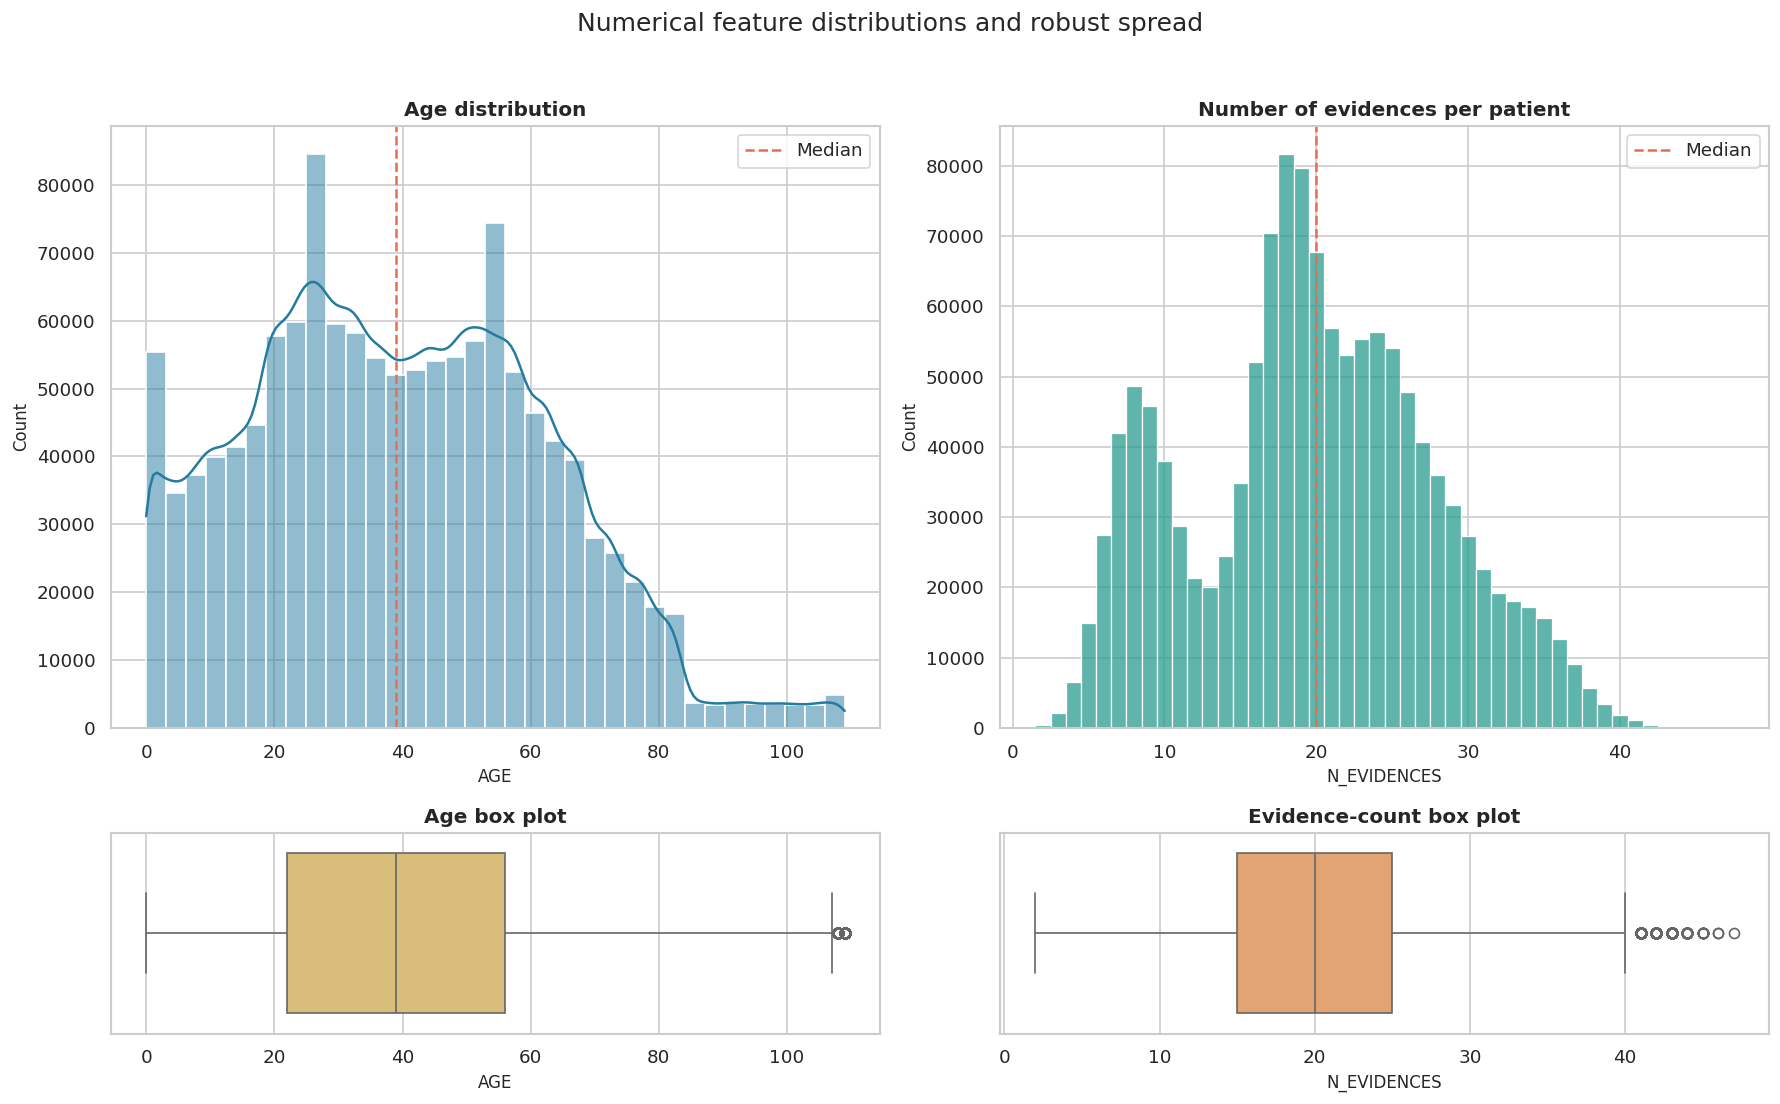

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(
    data=patients,
    x="AGE",
    bins=35,
    kde=True,
    color=PALETTE["blue"],
    ax=axes[0, 0],
)
axes[0, 0].axvline(patients["AGE"].median(), color=PALETTE["red"], linestyle="--", label="Median")
axes[0, 0].set_title("Age distribution")
axes[0, 0].legend()

sns.histplot(
    data=patients,
    x="N_EVIDENCES",
    discrete=True,
    color=PALETTE["teal"],
    ax=axes[0, 1],
)
axes[0, 1].axvline(
    patients["N_EVIDENCES"].median(), color=PALETTE["red"], linestyle="--", label="Median"
)
axes[0, 1].set_title("Number of evidences per patient")
axes[0, 1].legend()

sns.boxplot(x=patients["AGE"], color=PALETTE["gold"], ax=axes[1, 0])
axes[1, 0].set_title("Age box plot")

sns.boxplot(x=patients["N_EVIDENCES"], color=PALETTE["orange"], ax=axes[1, 1])
axes[1, 1].set_title("Evidence-count box plot")

fig.suptitle("Numerical feature distributions and robust spread", y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Target distribution and class imbalance

The dataset contains **49 pathologies**, with a largest to smallest class count ratio of **251.59:1**. Accuracy alone would therefore be dominated by common conditions.

The class frequency plot is used to motivate these 3 choices: **stratification**, **training-only imbalance handling** and **model selection by macro F1**. Balanced accuracy, macro sensitivity and per-pathology results are reported alongside accuracy.

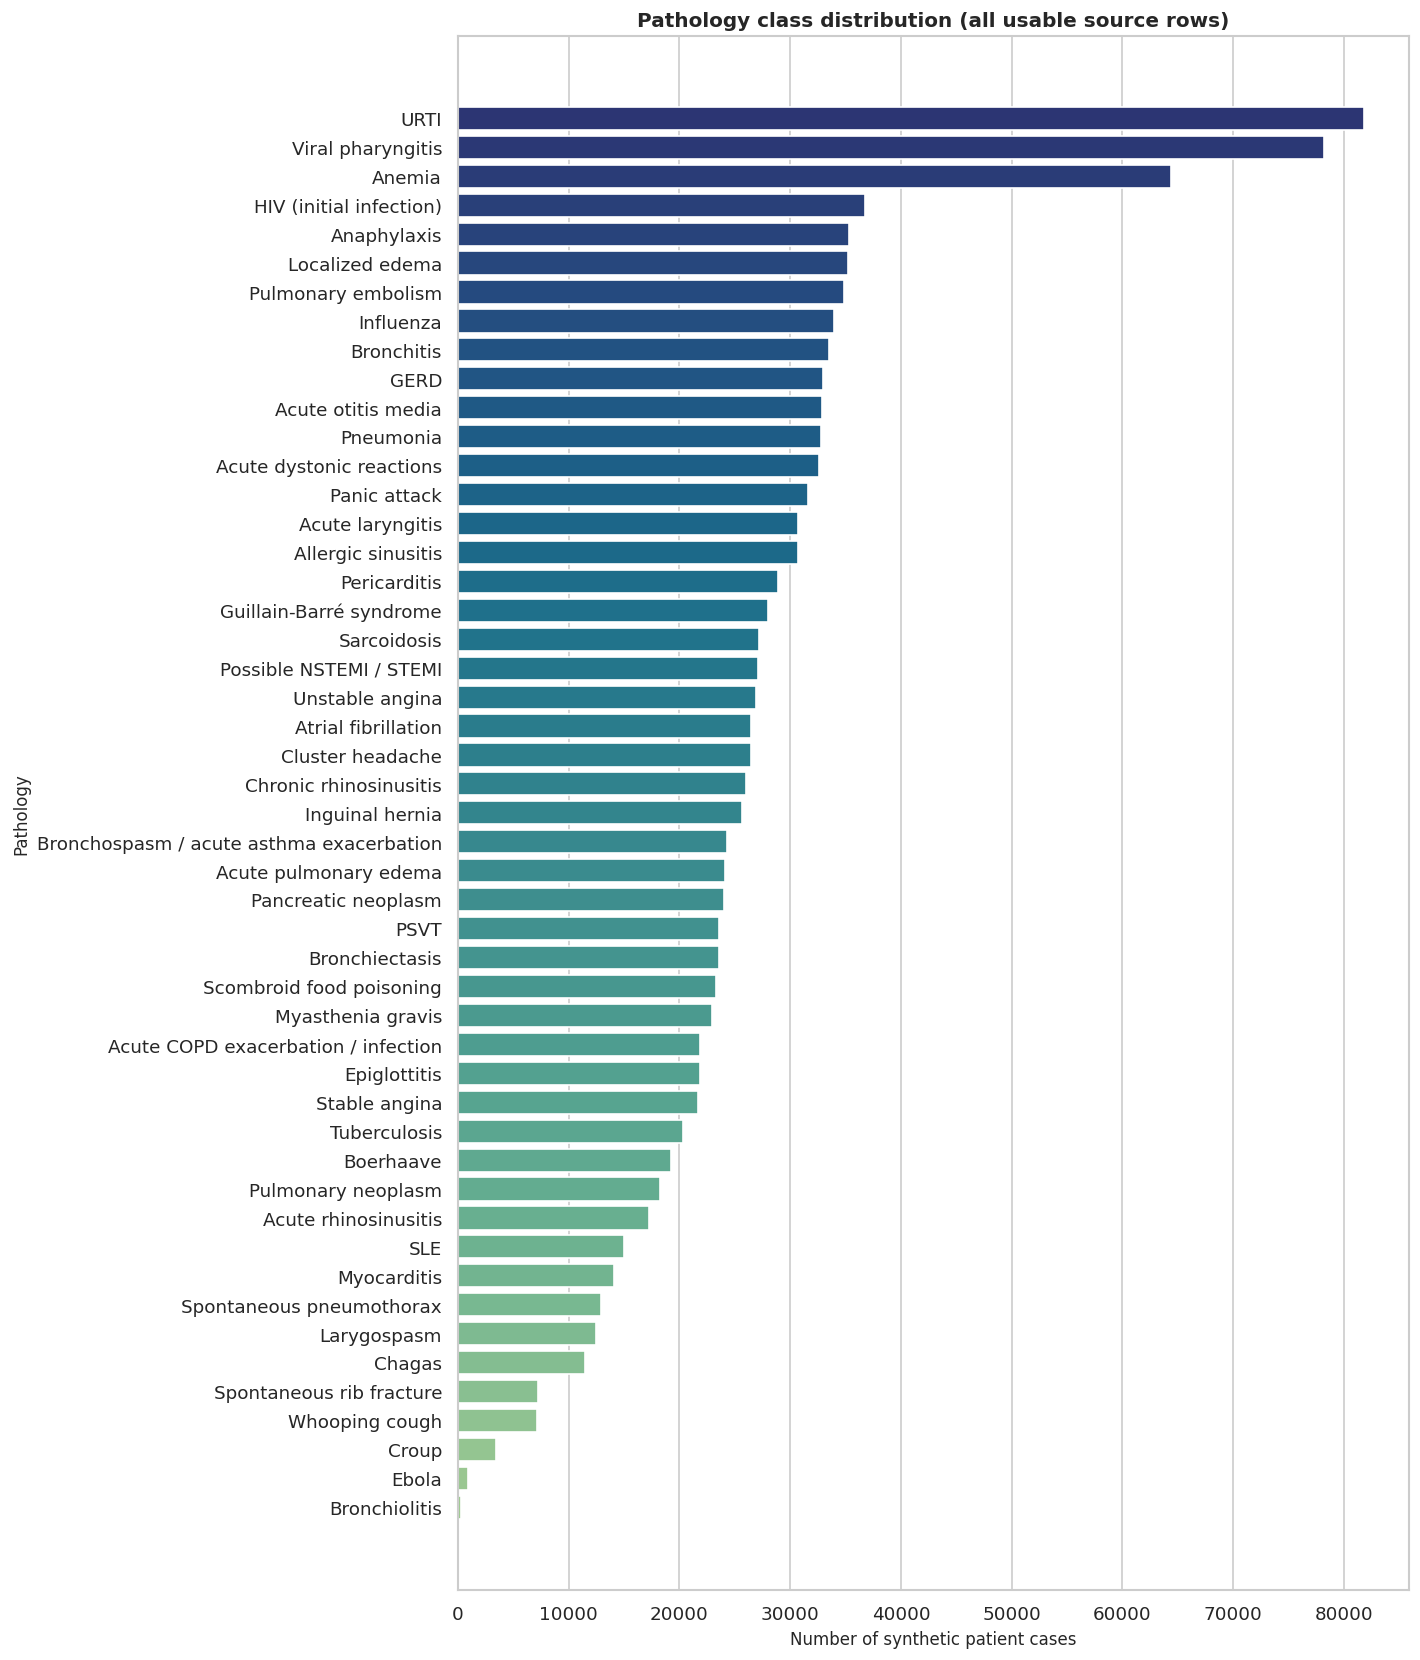

,count,percent
PATHOLOGY,,
URTI,81767,6.326%
Viral pharyngitis,78222,6.052%
Anemia,64410,4.983%
HIV (initial infection),36784,2.846%
Anaphylaxis,35271,2.729%
Localized edema,35253,2.727%
Pulmonary embolism,34872,2.698%
Influenza,33956,2.627%
Bronchitis,33537,2.595%


**Observed:** there are **49** target classes. The largest-to-smallest class-count ratio is **251.59:1**. Consequently, model selection will use validation **macro F1**, not accuracy alone.

In [10]:
class_counts = patients["PATHOLOGY"].value_counts().sort_values(ascending=True)
class_percent = 100 * class_counts / class_counts.sum()
imbalance_ratio = class_counts.max() / class_counts.min()

fig, ax = plt.subplots(figsize=(12, 14))
colors = sns.color_palette("crest", n_colors=len(class_counts))
ax.barh(class_counts.index, class_counts.values, color=colors)
ax.set_title("Pathology class distribution (all usable source rows)")
ax.set_xlabel("Number of synthetic patient cases")
ax.set_ylabel("Pathology")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

distribution_table = pd.DataFrame({"count": class_counts, "percent": class_percent})
display(distribution_table.sort_values("count", ascending=False).style.format({"percent": "{:.3f}%"}))
display(
    Markdown(
        f"**Observed:** there are **{len(class_counts)}** target classes. The largest-to-smallest "
        f"class-count ratio is **{imbalance_ratio:.2f}:1**. Consequently, model selection will use "
        "validation **macro F1**, not accuracy alone."
    )
)

### 5.3 Categorical composition

The following visualisations examine sex distribution, the most frequent initial evidences and sex composition within each pathology. The row-normalised heatmap expresses percentages within each pathology, allowing classes of different sizes to be compared. These are descriptive associations and must not be interpreted as causal effects.

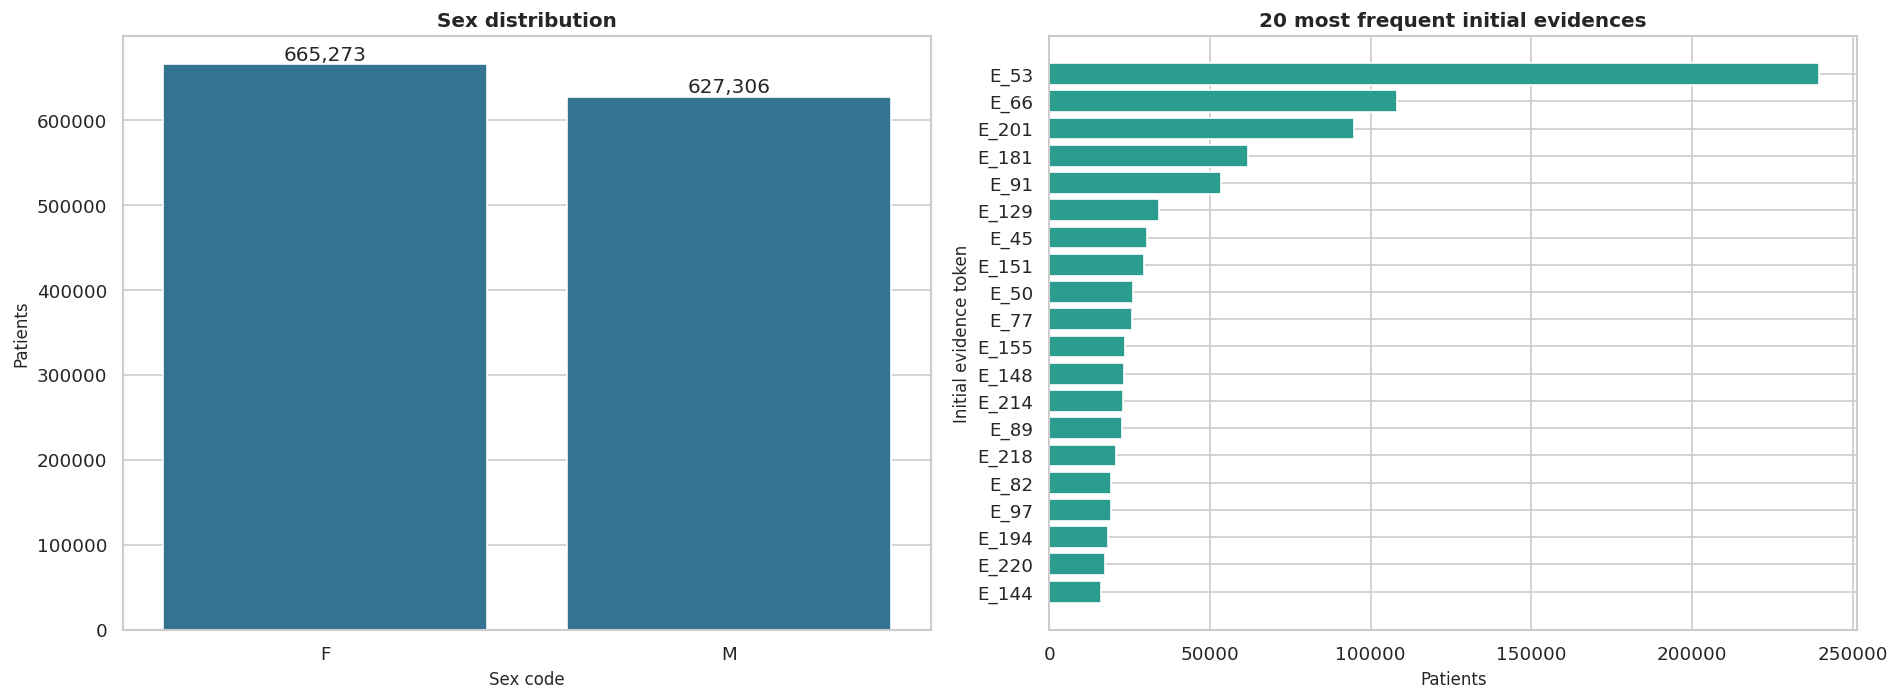

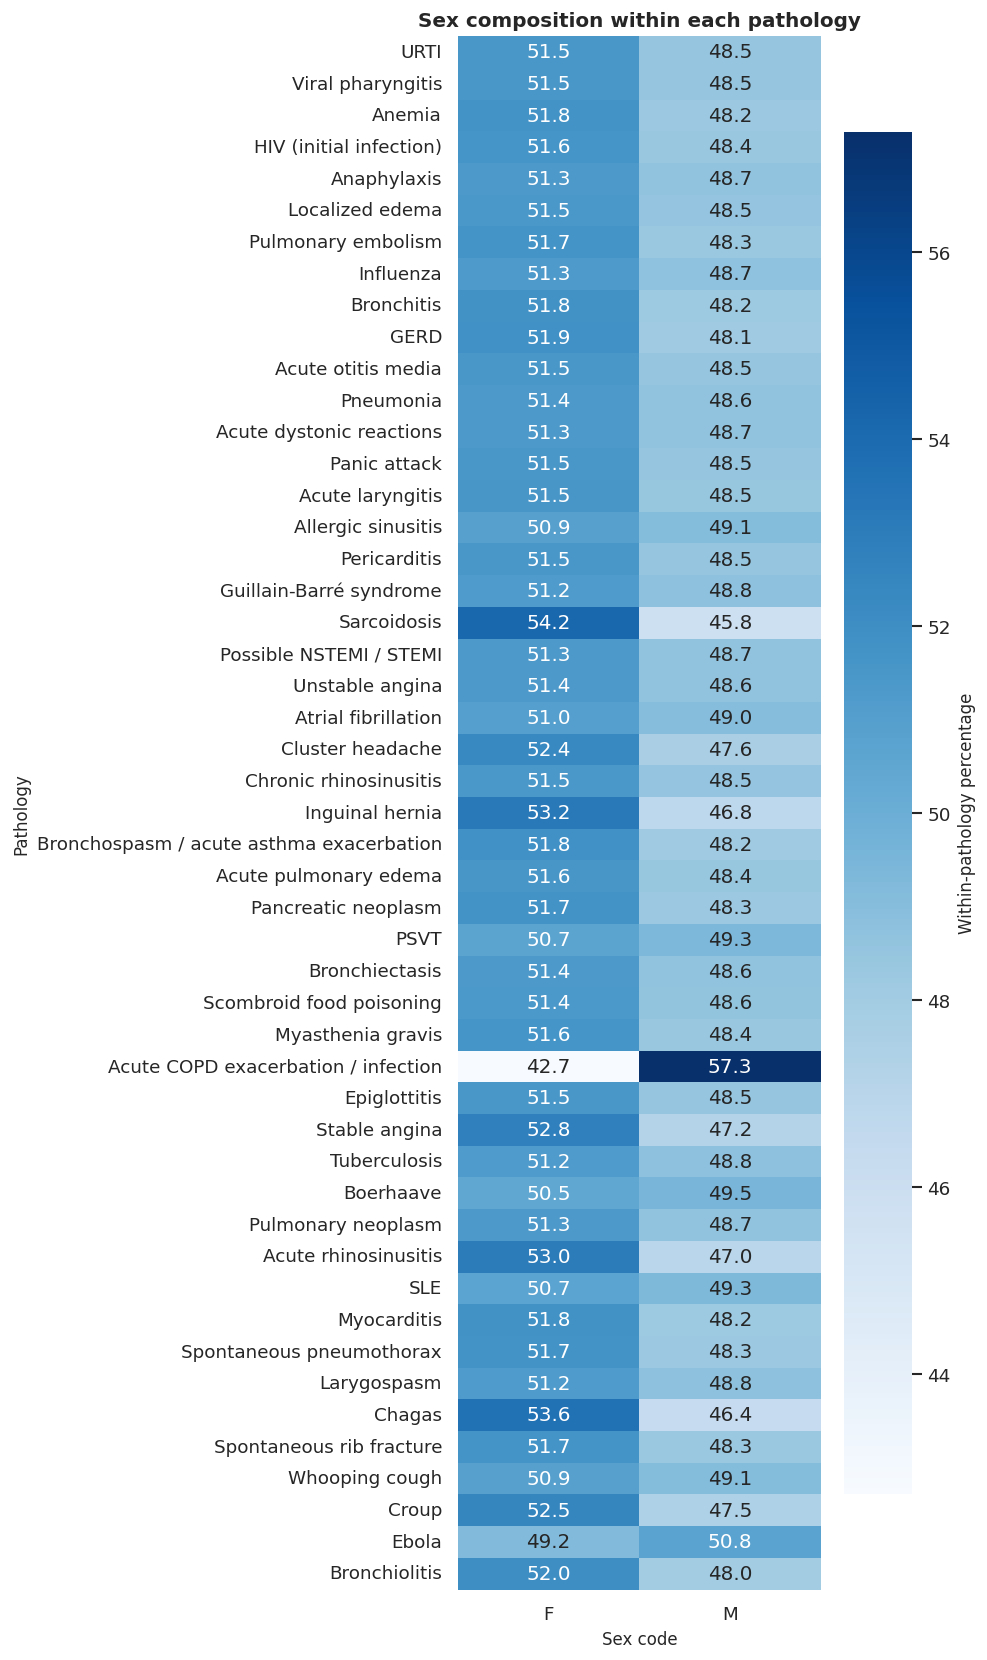

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sex_counts = patients["SEX"].value_counts().sort_index()
sns.barplot(x=sex_counts.index, y=sex_counts.values, color=PALETTE["blue"], ax=axes[0])
axes[0].set_title("Sex distribution")
axes[0].set_xlabel("Sex code")
axes[0].set_ylabel("Patients")
for patch, value in zip(axes[0].patches, sex_counts.values):
    axes[0].text(patch.get_x() + patch.get_width() / 2, value, f"{value:,}", ha="center", va="bottom")

initial_counts = patients["INITIAL_EVIDENCE"].value_counts().head(20).sort_values()
axes[1].barh(initial_counts.index, initial_counts.values, color=PALETTE["teal"])
axes[1].set_title("20 most frequent initial evidences")
axes[1].set_xlabel("Patients")
axes[1].set_ylabel("Initial evidence token")

plt.tight_layout()
plt.show()

sex_by_pathology = pd.crosstab(
    patients["PATHOLOGY"], patients["SEX"], normalize="index"
).reindex(class_counts.sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 14))
sns.heatmap(
    100 * sex_by_pathology,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Within-pathology percentage"},
    ax=ax,
)
ax.set_title("Sex composition within each pathology")
ax.set_xlabel("Sex code")
ax.set_ylabel("Pathology")
plt.tight_layout()
plt.show()

### 5.4 Evidence-token prevalence

`EVIDENCES` is a structured list rather than free text. Tokens may represent binary findings or coded values such as `E_54_@_V_161`. The analysis counts complete tokens, resolves readable descriptions from the metadata and plots the 25 most prevalent findings.

The saved execution observes **516 distinct complete evidence tokens**. Preserving the full token, including its value suffix, prevents different categorical answers from being collapsed into the same feature.

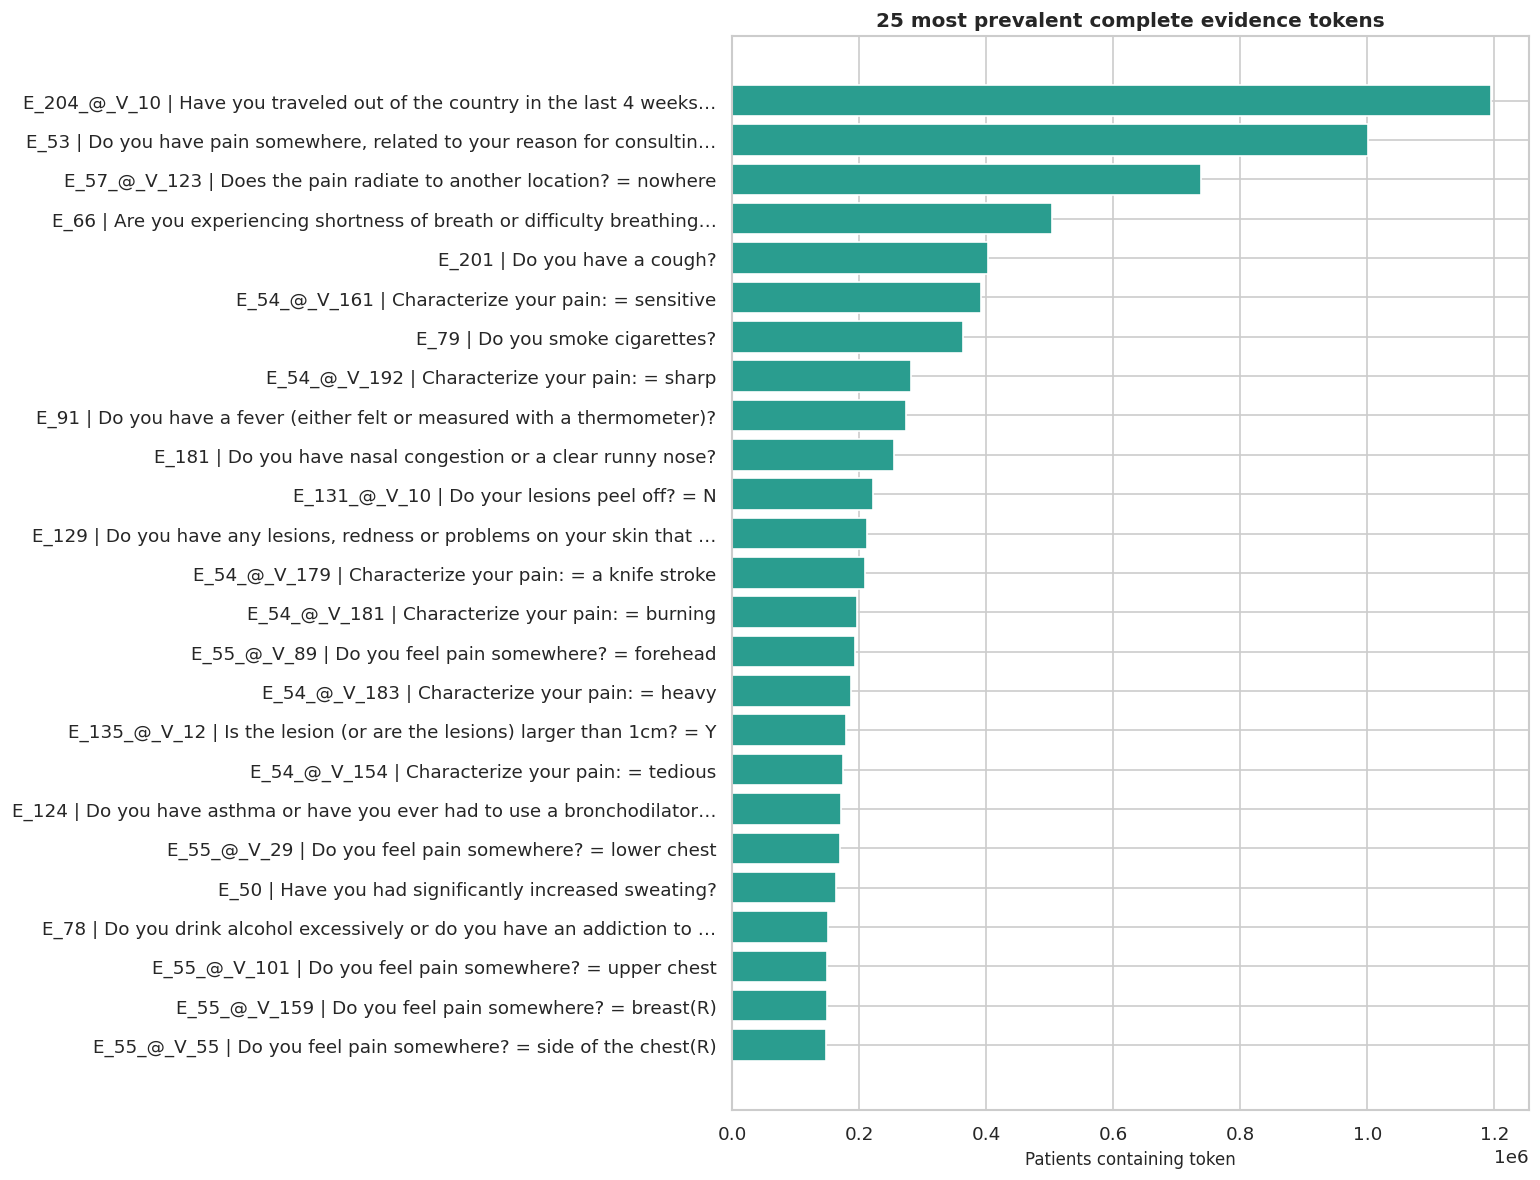

,token,count,prevalence_pct
0,E_204_@_V_10,1194404,92.405%
1,E_53,1000618,77.413%
2,E_57_@_V_123,737724,57.074%
3,E_66,503146,38.926%
4,E_201,402018,31.102%
5,E_54_@_V_161,391628,30.298%
6,E_79,363510,28.123%
7,E_54_@_V_192,281871,21.807%
8,E_91,274187,21.212%
9,E_181,254993,19.727%


Distinct complete evidence tokens observed: 516


In [12]:
def evidence_description(token: str, max_length: int = 72) -> str:
    base_code = token.split("_@_")[0]
    if not evidence_metadata or base_code not in evidence_metadata:
        return token
    meta = evidence_metadata[base_code]
    question = str(meta.get("question_en", base_code)).replace("\n", " ").strip()
    value_suffix = token.split("_@_", 1)[1] if "_@_" in token else None
    value_text = ""
    if value_suffix:
        meaning = meta.get("value_meaning", {}).get(value_suffix, {})
        if isinstance(meaning, dict):
            value_text = str(meaning.get("en", "")).strip()
    label = f"{token} | {question}"
    if value_text:
        label += f" = {value_text}"
    return label if len(label) <= max_length else label[: max_length - 1] + "…"


token_counts = Counter(chain.from_iterable(patients["EVIDENCES"]))
top_tokens = pd.DataFrame(token_counts.most_common(25), columns=["token", "count"])
top_tokens["prevalence_pct"] = 100 * top_tokens["count"] / len(patients)
top_tokens["display_label"] = top_tokens["token"].map(evidence_description)

fig, ax = plt.subplots(figsize=(13, 10))
plot_tokens = top_tokens.sort_values("count")
ax.barh(plot_tokens["display_label"], plot_tokens["count"], color=PALETTE["teal"])
ax.set_title("25 most prevalent complete evidence tokens")
ax.set_xlabel("Patients containing token")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(top_tokens[["token", "count", "prevalence_pct"]].style.format({"prevalence_pct": "{:.3f}%"}))
print(f"Distinct complete evidence tokens observed: {len(token_counts):,}")

### 5.5 Relationships among observed variables

Pearson correlation is restricted to numerical encodings: age, number of evidences and a binary indicator for `SEX=F`. The pathology label is nominal and is not assigned an artificial numeric order. Age distributions are then compared across the 12 most frequent pathologies with box plots.

A separate chart summarises the severity levels contained in the condition metadata. Severity is shown for domain context only and remains excluded from model training.

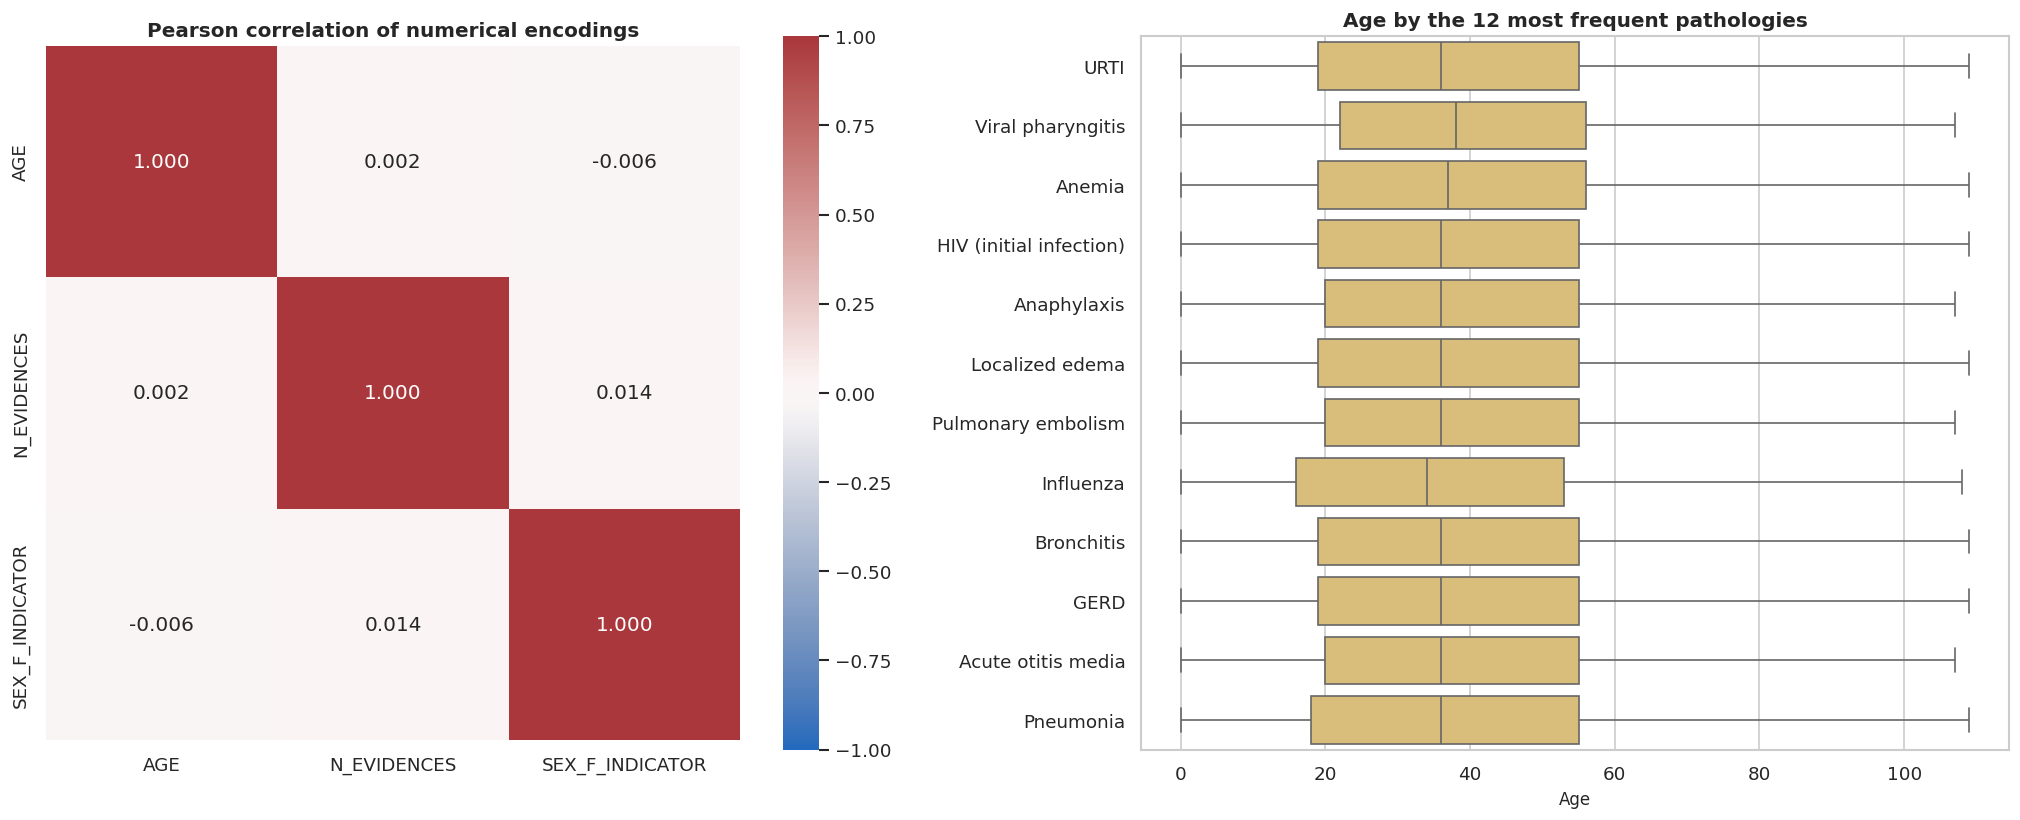

In [13]:
numeric_relationships = pd.DataFrame(
    {
        "AGE": patients["AGE"].astype(float),
        "N_EVIDENCES": patients["N_EVIDENCES"].astype(float),
        "SEX_F_INDICATOR": patients["SEX"].eq("F").astype(float),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.heatmap(
    numeric_relationships.corr(method="pearson"),
    annot=True,
    fmt=".3f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    square=True,
    ax=axes[0],
)
axes[0].set_title("Pearson correlation of numerical encodings")

top_pathologies = patients["PATHOLOGY"].value_counts().head(12).index.tolist()
age_plot_source = patients.loc[patients["PATHOLOGY"].isin(top_pathologies), ["AGE", "PATHOLOGY"]]
if len(age_plot_source) > 120_000:
    age_plot_source = age_plot_source.sample(120_000, random_state=RANDOM_STATE)
sns.boxplot(
    data=age_plot_source,
    x="AGE",
    y="PATHOLOGY",
    order=top_pathologies,
    color=PALETTE["gold"],
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Age by the 12 most frequent pathologies")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

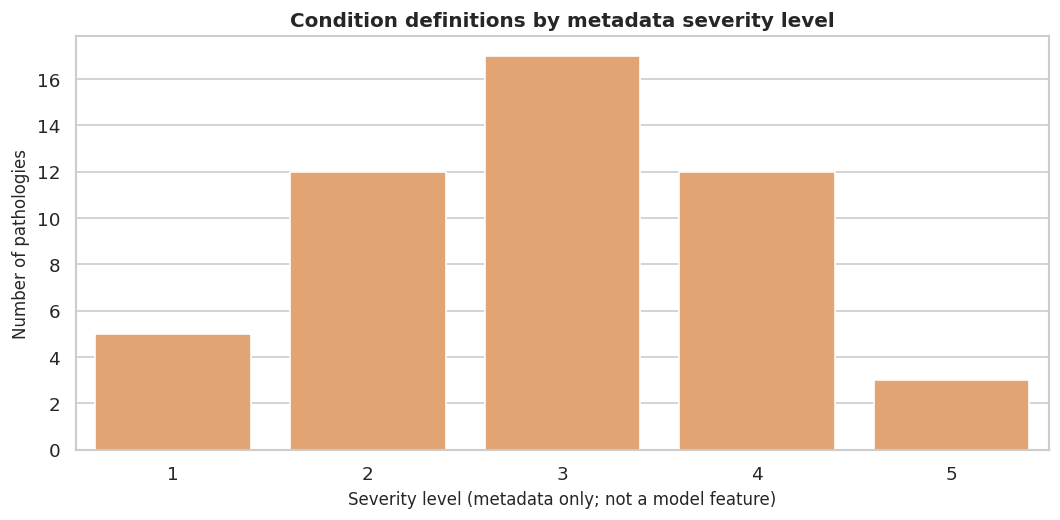

,pathology,severity,icd10_id
0,Acute pulmonary edema,1,J81.0
1,Anaphylaxis,1,T78.0
2,Ebola,1,a98.4
3,Larygospasm,1,J38.5
4,Possible NSTEMI / STEMI,1,I21
5,Acute dystonic reactions,2,G24.02
6,Boerhaave,2,K22.3
7,Croup,2,J05.0
8,Epiglottitis,2,J05.1
9,Guillain-Barré syndrome,2,G61.0


In [14]:
if condition_metadata:
    severity_table = pd.DataFrame(
        [
            {
                "pathology": name,
                "severity": details.get("severity"),
                "icd10_id": details.get("icd10-id"),
            }
            for name, details in condition_metadata.items()
        ]
    )
    severity_counts = severity_table["severity"].value_counts(dropna=False).sort_index()
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.barplot(x=severity_counts.index.astype(str), y=severity_counts.values, color=PALETTE["orange"], ax=ax)
    ax.set_title("Condition definitions by metadata severity level")
    ax.set_xlabel("Severity level (metadata only; not a model feature)")
    ax.set_ylabel("Number of pathologies")
    plt.tight_layout()
    plt.show()
    display(severity_table.sort_values(["severity", "pathology"]).reset_index(drop=True))
else:
    print("Condition metadata was not found; severity context is skipped without affecting modelling.")

## 6. Feature engineering and leakage control

The feature pipeline mirrors the request schema used by the ED²A API:

1. `AGE` is standardised using parameters learned from the training set.
2. `SEX` is one-hot encoded with unknown-category tolerance.
3. `EVIDENCES` is converted into a sparse binary bag of complete evidence tokens with `CountVectorizer(analyzer=list, binary=True)`.
4. `INITIAL_EVIDENCE` is one-hot encoded.
5. `PATHOLOGY` is transformed with `LabelEncoder`.
6. `DIFFERENTIAL_DIAGNOSIS` is never loaded into the feature matrix.

The preprocessor is fitted after splitting and after training-only augmentation. Validation and test rows cannot affect scaling statistics, vocabularies, categories or augmentation decisions.

## 7. Stratified split and training only data augmentation

### 7.1 Holdout protocol

Two deterministic stratified splits produce 70% training, 20% validation and 10% test data. The validation partition drives hyperparameter search, early stopping and model selection.

### 7.2 Evidence-masking augmentation

The notebook applies a conservative, training only augmentation to under represented pathologies:

- classes below the first quartile of training frequency are eligible;
- at most 2,000 augmented rows are added per eligible class;
- each augmented copy removes one non initial evidence while preserving age, sex, initial evidence and target;
- validation and test profiles are never augmented;
- a fixed random seed makes the procedure reproducible.

This simulates incomplete symptom reporting without inventing a positive clinical finding. It remains an experimental robustness strategy and is evaluated only through held out metrics.

In [15]:
FEATURE_COLUMNS = ["AGE", "SEX", "EVIDENCES", "INITIAL_EVIDENCE"]
TARGET_COLUMN = "PATHOLOGY"

model_frame = patients[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()

train_frame, holdout_frame = train_test_split(
    model_frame,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=model_frame[TARGET_COLUMN],
)
validation_frame, test_frame = train_test_split(
    holdout_frame,
    test_size=1 / 3,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=holdout_frame[TARGET_COLUMN],
)

split_table = pd.DataFrame(
    {
        "rows": [len(train_frame), len(validation_frame), len(test_frame)],
    },
    index=["Training", "Validation", "Test"],
)
split_table["percent"] = 100 * split_table["rows"] / split_table["rows"].sum()
display(split_table.style.format({"percent": "{:.3f}%"}))

split_proportions = pd.concat(
    {
        "Training": train_frame[TARGET_COLUMN].value_counts(normalize=True),
        "Validation": validation_frame[TARGET_COLUMN].value_counts(normalize=True),
        "Test": test_frame[TARGET_COLUMN].value_counts(normalize=True),
    },
    axis=1,
).fillna(0)
max_deviation = (
    split_proportions.max(axis=1) - split_proportions.min(axis=1)
).max()

print(f"Maximum class-proportion spread across splits: {max_deviation:.6f}")
assert abs(len(train_frame) / len(model_frame) - 0.70) < 0.001
assert abs(len(validation_frame) / len(model_frame) - 0.20) < 0.001
assert abs(len(test_frame) / len(model_frame) - 0.10) < 0.001
assert train_frame.index.intersection(validation_frame.index).empty
assert train_frame.index.intersection(test_frame.index).empty
assert validation_frame.index.intersection(test_frame.index).empty

del patients, model_frame, holdout_frame
gc.collect()

,rows,percent
Training,904805,70.000%
Validation,258516,20.000%
Test,129258,10.000%


Maximum class-proportion spread across splits: 0.000004


30283

,before,after,added
PATHOLOGY,,,
Bronchiolitis,228,2228,2000
Ebola,636,2636,2000
Croup,2424,4424,2000
Whooping cough,5015,7015,2000
Spontaneous rib fracture,5090,7090,2000
Chagas,8017,10017,2000
Larygospasm,8716,10716,2000
Spontaneous pneumothorax,9037,11037,2000
Myocarditis,9869,11869,2000


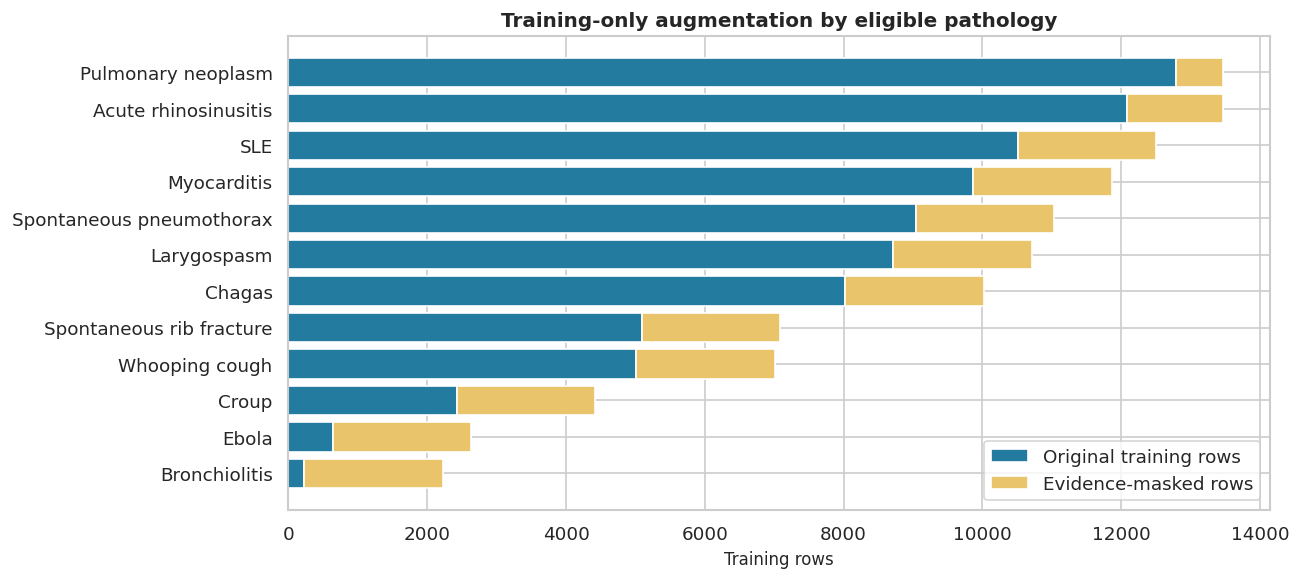

Training rows: 904,805 before augmentation; 926,862 after augmentation (22,057 added).


,rows,features,non_zero_values
Training (augmented),926862,611,20960449
Validation,258516,611,5889453
Test,129258,611,2943306


Sparse training-matrix density: 3.7012%
Preprocessing time: 13.92 seconds
Number of target classes: 49
First transformed feature names: ['age__AGE', 'sex__SEX_F', 'sex__SEX_M', 'evidences__E_0', 'evidences__E_1', 'evidences__E_10', 'evidences__E_100', 'evidences__E_101', 'evidences__E_102', 'evidences__E_103']


In [ ]:
# Conservative training only augmentation: remove one secondary evidence from
#  selected minority-class profiles to simulate incomplete symptom reporting.
# !! Qui da capire se effettivamente ha senso fare oversampling per un max di 2000 immagini. Probabilmente aggiungere più immagini per classi veramente piccole
#  porterebbe ad overfitting. !!
def mask_one_secondary_evidence(
    evidences: list[str],
    initial_evidence: str,
    rng: np.random.Generator,
) -> list[str]:
    tokens = list(evidences)
    if len(tokens) <= 2:
        return tokens

    initial_code = str(initial_evidence).split("_@_", 1)[0]
    removable_positions = [
        position
        for position, token in enumerate(tokens)
        if str(token).split("_@_", 1)[0] != initial_code
    ]
    if not removable_positions:
        return tokens

    del tokens[int(rng.choice(removable_positions))]
    return tokens


ORIGINAL_USABLE_ROWS = len(train_frame) + len(validation_frame) + len(test_frame)
training_rows_before_augmentation = len(train_frame)
training_counts_before = train_frame[TARGET_COLUMN].value_counts()
augmentation_target_count = int(
    training_counts_before.quantile(AUGMENTATION_TARGET_QUANTILE, interpolation="higher")
)

augmented_batches = []
for class_offset, (pathology, class_count) in enumerate(training_counts_before.items()):
    rows_to_add = min(
        max(0, augmentation_target_count - int(class_count)),
        AUGMENTATION_MAX_PER_CLASS,
    )
    if rows_to_add == 0:
        continue

    class_rows = train_frame.loc[train_frame[TARGET_COLUMN].eq(pathology)]
    eligible_rows = class_rows.loc[class_rows["EVIDENCES"].map(len).gt(2)]
    if eligible_rows.empty:
        continue

    sampled_rows = eligible_rows.sample(
        n=rows_to_add,
        replace=rows_to_add > len(eligible_rows),
        random_state=RANDOM_STATE + class_offset,
    ).copy()
    class_rng = np.random.default_rng(RANDOM_STATE + 10_000 + class_offset)
    sampled_rows["EVIDENCES"] = [
        mask_one_secondary_evidence(evidences, initial_evidence, class_rng)
        for evidences, initial_evidence in zip(
            sampled_rows["EVIDENCES"],
            sampled_rows["INITIAL_EVIDENCE"],
        )
    ]
    augmented_batches.append(sampled_rows)

if augmented_batches:
    train_frame = pd.concat([train_frame, *augmented_batches], ignore_index=True)
else:
    train_frame = train_frame.reset_index(drop=True)

augmentation_rows_added = len(train_frame) - training_rows_before_augmentation
training_counts_after = train_frame[TARGET_COLUMN].value_counts()
augmentation_summary = (
    pd.concat(
        [
            training_counts_before.rename("before"),
            training_counts_after.rename("after"),
        ],
        axis=1,
    )
    .fillna(0)
    .astype(int)
)
augmentation_summary["added"] = augmentation_summary["after"] - augmentation_summary["before"]
augmentation_summary = augmentation_summary.sort_values(["added", "before"], ascending=[False, True])

display(augmentation_summary.head(20))

augmented_classes = augmentation_summary.loc[augmentation_summary["added"].gt(0)].sort_values("after")
if not augmented_classes.empty:
    fig, ax = plt.subplots(figsize=(11, max(5, 0.38 * len(augmented_classes))))
    ax.barh(
        augmented_classes.index,
        augmented_classes["before"],
        color=PALETTE["blue"],
        label="Original training rows",
    )
    ax.barh(
        augmented_classes.index,
        augmented_classes["added"],
        left=augmented_classes["before"],
        color=PALETTE["gold"],
        label="Evidence-masked rows",
    )
    ax.set_title("Training-only augmentation by eligible pathology")
    ax.set_xlabel("Training rows")
    ax.set_ylabel("")
    ax.legend()
    plt.tight_layout()
    plt.show()

print(
    f"Training rows: {training_rows_before_augmentation:,} before augmentation; "
    f"{len(train_frame):,} after augmentation ({augmentation_rows_added:,} added)."
)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_frame[TARGET_COLUMN])
y_validation = label_encoder.transform(validation_frame[TARGET_COLUMN])
y_test = label_encoder.transform(test_frame[TARGET_COLUMN])
class_names = label_encoder.classes_.astype(str)
N_CLASSES = len(class_names)

preprocessor = ColumnTransformer(
    transformers=[
        ("age", StandardScaler(), ["AGE"]),
        (
            "sex",
            OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32),
            ["SEX"],
        ),
        (
            "evidences",
            CountVectorizer(analyzer=list, binary=True, dtype=np.float32),
            "EVIDENCES",
        ),
        (
            "initial",
            OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32),
            ["INITIAL_EVIDENCE"],
        ),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=True,
)

transform_start = time.perf_counter()
X_train = preprocessor.fit_transform(train_frame[FEATURE_COLUMNS])
X_validation = preprocessor.transform(validation_frame[FEATURE_COLUMNS])
X_test = preprocessor.transform(test_frame[FEATURE_COLUMNS])
transform_seconds = time.perf_counter() - transform_start

if not sparse.issparse(X_train):
    X_train = sparse.csr_matrix(X_train)
    X_validation = sparse.csr_matrix(X_validation)
    X_test = sparse.csr_matrix(X_test)
else:
    X_train = X_train.tocsr()
    X_validation = X_validation.tocsr()
    X_test = X_test.tocsr()

feature_names = preprocessor.get_feature_names_out()
density = X_train.nnz / (X_train.shape[0] * X_train.shape[1])

matrix_summary = pd.DataFrame(
    {
        "rows": [X_train.shape[0], X_validation.shape[0], X_test.shape[0]],
        "features": [X_train.shape[1], X_validation.shape[1], X_test.shape[1]],
        "non_zero_values": [X_train.nnz, X_validation.nnz, X_test.nnz],
    },
    index=["Training (augmented)", "Validation", "Test"],
)
display(matrix_summary)
print(f"Sparse training-matrix density: {density:.4%}")
print(f"Preprocessing time: {transform_seconds:.2f} seconds")
print(f"Number of target classes: {N_CLASSES}")
print("First transformed feature names:", feature_names[:10].tolist())

assert len(train_frame) >= training_rows_before_augmentation
assert X_train.shape[1] == X_validation.shape[1] == X_test.shape[1]
assert set(np.unique(y_train)) == set(range(N_CLASSES))
assert set(np.unique(y_validation)) == set(range(N_CLASSES))
assert set(np.unique(y_test)) == set(range(N_CLASSES))

## 8. Class imbalance handling

After augmentation, balanced class weights are computed from the training labels and supplied to both model-training strategies. This avoids expanding every minority class to the majority count, which would substantially increase runtime and duplicate a large number of profiles.

The evaluation metrics are not reweighted: validation and test results describe the natural held out distributions. FLAML's additional `auto_augment` option is disabled so that both strategies receive the same explicitly constructed training matrix and the comparison remains controlled.

In [17]:
encoded_classes = np.arange(N_CLASSES)
class_weight_values = compute_class_weight(
    class_weight="balanced", classes=encoded_classes, y=y_train
)
train_sample_weight = class_weight_values[y_train].astype(np.float32)
validation_sample_weight = class_weight_values[y_validation].astype(np.float32)

weight_table = pd.DataFrame(
    {
        "pathology": class_names,
        "training_count": np.bincount(y_train, minlength=N_CLASSES),
        "class_weight": class_weight_values,
    }
).sort_values("class_weight", ascending=False)
display(weight_table.style.format({"class_weight": "{:.4f}"}))

,pathology,training_count,class_weight
12,Bronchiolitis,2228,8.4899
19,Ebola,2636,7.1759
18,Croup,4424,4.2757
48,Whooping cough,7015,2.6964
42,Spontaneous rib fracture,7090,2.6679
15,Chagas,10017,1.8883
26,Larygospasm,10716,1.7652
41,Spontaneous pneumothorax,11037,1.7138
29,Myocarditis,11869,1.5937
38,SLE,12507,1.5124


## 9. FLAML AutoML - 100 trial budget

FLAML searches across XGBoost, Random Forest and Extra Trees using validation macro F1 as the objective. `max_iter=100` sets the maximum number of model and hyper-parameter configurations, while `early_stop=True` allows the search to terminate when the estimator-specific searches have converged.

Progressive sampling is enabled to reduce the cost of searching a dataset with more than one million rows. The test set is never exposed to FLAML. After the search, the best underlying estimator is cloned and fitted once on the complete augmented training matrix; validation data are not included in this refit.

The logged history is used to plot trial scores and the best validation macro F1. All counters are derived from completed trials rather than from the configured cap.

During execution, `verbose=3` enables FLAML's INFO level progress messages so that each completed search trial reports its estimator, configuration and current validation result. The complete history is also retained in the trial log used by the following diagnostic plots.

In [ ]:
from flaml import AutoML
from flaml.automl.data import get_output_from_log

WORKING_ROOT = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
FLAML_LOG = WORKING_ROOT / f"flaml_ddxplus_{FLAML_ITERATIONS}_trials.log"

# Refresho il log per evitare di avere artefatti di training precedenti
if FLAML_LOG.exists():
    FLAML_LOG.unlink()

# Estimator specific fit arguments prevent GPU options from being forwarded
# to the scikit-learn forest estimators, whose fit() methods do not accept them.
flaml_fit_kwargs_by_estimator = {
    "xgboost": {"gpu_per_trial": 1 if GPU_AVAILABLE else 0},
    "rf": {},
    "extra_tree": {},
}

automl = AutoML()
print(
    f"[FLAML] Starting search: up to {FLAML_ITERATIONS} trials "
    f"across xgboost, rf and extra_tree."
)
flaml_search_start = time.perf_counter()

automl.fit(
    X_train=X_train,
    y_train=y_train,
    X_val=X_validation,
    y_val=y_validation,
    sample_weight=train_sample_weight,
    sample_weight_val=validation_sample_weight,
    task="classification",
    metric="macro_f1",
    estimator_list=["xgboost", "rf", "extra_tree"],
    eval_method="holdout",
    max_iter=FLAML_ITERATIONS,
    time_budget=-1,
    early_stop=FLAML_NATIVE_EARLY_STOP,
    auto_augment=FLAML_AUTO_AUGMENT,
    sample=True,
    retrain_full=False,
    n_jobs=N_JOBS,
    seed=RANDOM_STATE,
    log_file_name=str(FLAML_LOG),
    log_type="all",
    mlflow_logging=False,
    fit_kwargs_by_estimator=flaml_fit_kwargs_by_estimator,
    verbose=3,  # voglio vedere le varie iterazioni altrimenti non so quando finisce!!
    use_spark=False,
    use_ray=False,
)

flaml_search_seconds = time.perf_counter() - flaml_search_start
print(f"[FLAML] Search completed in {flaml_search_seconds:.1f} seconds.")


def count_logged_flaml_trials(log_path: Path) -> int:
    """Return the number of trials written to the FLAML log."""
    try:
        _, _, logged_trial_losses, _, _ = get_output_from_log(
            filename=str(log_path),
            time_budget=np.inf,
        )
        return int(len(logged_trial_losses))
    except Exception:
        return int(getattr(automl, "best_iteration", -1)) + 1


flaml_completed_trials = count_logged_flaml_trials(FLAML_LOG)
flaml_stopped_early = flaml_completed_trials < FLAML_ITERATIONS

# Refit the selected estimator on the complete augmented training matrix only.
flaml_best_template = automl.model.estimator
flaml_model = clone(flaml_best_template)
print(f"[FLAML] Refitting best estimator: {automl.best_estimator}.")
flaml_refit_start = time.perf_counter()
flaml_model.fit(X_train, y_train, sample_weight=train_sample_weight)
flaml_refit_seconds = time.perf_counter() - flaml_refit_start
print(f"[FLAML] Full-training refit completed in {flaml_refit_seconds:.1f} seconds.")

flaml_summary = pd.DataFrame(
    {
        "item": [
            "Maximum requested AutoML trials",
            "Completed / logged AutoML trials",
            "Convergence-based early stopping",
            "Stopped before the trial cap",
            "FLAML automatic rare-class augmentation",
            "Best estimator family",
            "Best validation macro F1",
            "Search seconds",
            "Full-training refit seconds",
            "Serving estimator class",
        ],
        "value": [
            FLAML_ITERATIONS,
            flaml_completed_trials,
            "enabled" if FLAML_NATIVE_EARLY_STOP else "disabled",
            "yes" if flaml_stopped_early else "no",
            "enabled" if FLAML_AUTO_AUGMENT else "disabled",
            automl.best_estimator,
            1 - automl.best_loss,
            flaml_search_seconds,
            flaml_refit_seconds,
            f"{type(flaml_model).__module__}.{type(flaml_model).__name__}",
        ],
    }
)
display(flaml_summary)
print(
    f"FLAML logged {flaml_completed_trials} of at most {FLAML_ITERATIONS} search trials "
    f"(native early_stop={FLAML_NATIVE_EARLY_STOP})."
)
print("Best FLAML configuration:")
display(pd.Series(automl.best_config, name="value").to_frame())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/28 19:17:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


[FLAML] Starting search: up to 100 trials across xgboost, rf and extra_tree.
[flaml.automl.logger: 08-28 19:17:32] {2375} INFO - task = classification
[flaml.automl.logger: 08-28 19:17:32] {2383} INFO - Data split method: stratified
[flaml.automl.logger: 08-28 19:17:32] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-28 19:17:32] {2489} INFO - Minimizing error metric: 1-macro_f1
[flaml.automl.logger: 08-28 19:17:32] {2606} INFO - List of ML learners in AutoML Run: ['xgboost', 'rf', 'extra_tree']
[flaml.automl.logger: 08-28 19:17:32] {2911} INFO - iteration 0, current learner xgboost
[flaml.automl.logger: 08-28 19:17:33] {3046} INFO - Estimated sufficient time budget=926862s. Estimated necessary time budget=927s.
[flaml.automl.logger: 08-28 19:17:33] {3097} INFO -  at 0.9s,	estimator xgboost's best error=2.9905e-02,	best estimator xgboost's best error=2.9905e-02
[flaml.automl.logger: 08-28 19:17:33] {2911} INFO - iteration 1, current learner xgboost
[flaml.automl.logge

,item,value
0,Maximum requested AutoML trials,100
1,Completed / logged AutoML trials,100
2,Convergence-based early stopping,enabled
3,Stopped before the trial cap,no
4,FLAML automatic rare-class augmentation,disabled
5,Best estimator family,xgboost
6,Best validation macro F1,0.996989
7,Search seconds,13581.542829
8,Full-training refit seconds,220.296739
9,Serving estimator class,xgboost.sklearn.XGBClassifier


FLAML logged 100 of at most 100 search trials (native early_stop=True).
Best FLAML configuration:


,value
n_estimators,738.000000
max_leaves,4.000000
min_child_weight,0.024402
learning_rate,0.113905
subsample,0.716155
colsample_bylevel,0.411593
colsample_bytree,1.000000
reg_alpha,0.002364
reg_lambda,9.431833


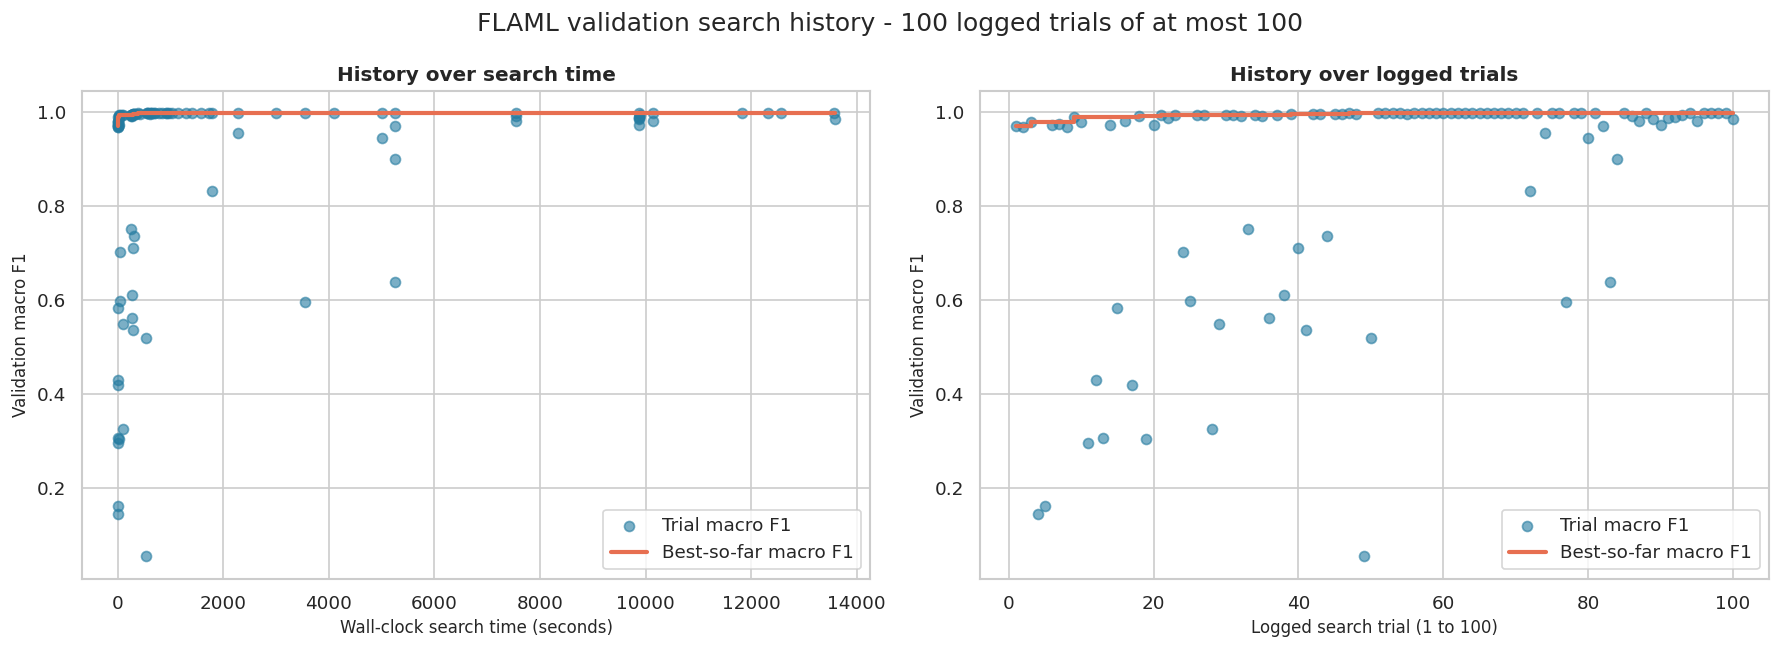

Completed/logged FLAML trials: 100 (requested maximum: 100)
Native convergence-based early stopping (early_stop): enabled
FLAML used the full trial budget.


In [47]:
(
    flaml_time_history,
    flaml_best_loss_history,
    flaml_trial_loss_history,
    flaml_config_history,
    flaml_metric_history,
) = get_output_from_log(filename=str(FLAML_LOG), time_budget=np.inf)

flaml_trial_scores = 1 - np.asarray(flaml_trial_loss_history, dtype=float)
flaml_best_scores = 1 - np.asarray(flaml_best_loss_history, dtype=float)

# Every counter and axis below is driven by the trials actually logged, never by the cap,
# so the cell is correct whether FLAML converged early or used the full configured budget.
flaml_logged_trials = int(flaml_trial_scores.size)
flaml_completed_trials = flaml_logged_trials
flaml_stopped_early = flaml_logged_trials < FLAML_ITERATIONS
flaml_trial_index = np.arange(1, flaml_logged_trials + 1)

if flaml_logged_trials == 0:
    print("No FLAML trials were logged, so there is no search history to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, x_values, x_label, panel_title in [
        (axes[0], flaml_time_history, "Wall-clock search time (seconds)", "History over search time"),
        (axes[1], flaml_trial_index, f"Logged search trial (1 to {flaml_logged_trials})", "History over logged trials"),
    ]:
        ax.scatter(x_values, flaml_trial_scores, alpha=0.60, color=PALETTE["blue"], label="Trial macro F1")
        ax.step(
            x_values,
            flaml_best_scores,
            where="post",
            linewidth=2.5,
            color=PALETTE["red"],
            label="Best-so-far macro F1",
        )
        ax.set_title(panel_title)
        ax.set_xlabel(x_label)
        ax.set_ylabel("Validation macro F1")
        ax.legend()
    fig.suptitle(
        f"FLAML validation search history - {flaml_logged_trials} logged trials "
        f"of at most {FLAML_ITERATIONS}"
    )
    plt.tight_layout()
    plt.show()

print(f"Completed/logged FLAML trials: {flaml_logged_trials} (requested maximum: {FLAML_ITERATIONS})")
print(
    "Native convergence-based early stopping (early_stop): "
    f"{'enabled' if FLAML_NATIVE_EARLY_STOP else 'disabled'}"
)
if flaml_stopped_early:
    print("FLAML converged and stopped before reaching the trial cap.")
else:
    print("FLAML used the full trial budget.")

## 10. Standalone XGBoost - 100 rounds with validation early stopping

The second strategy is a manually specified multiclass XGBoost model. It uses shallow regularised trees, row and column subsampling, balanced sample weights and a learning rate of 0.05.

Training is capped at **100 boosting rounds**. A fresh `EarlyStopping` callback monitors validation `mlogloss` and stops after **20 consecutive non improving rounds**. The validation set is the last entry in `eval_set`; the test set is never passed to training. With `save_best=True`, the retained booster is truncated to the best validation round.

Training and validation log loss and classification error are plotted across the rounds actually executed.

XGBoost is fitted with `verbose=1`, which prints one compact line for every boosting round. Each line contains training and validation `mlogloss` and `merror`, making both progress and the onset of overfitting visible while the model is running.

In [ ]:
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping


def build_early_stopping_callback() -> EarlyStopping:
    """Return a *fresh* callback: an EarlyStopping object holds state and must not be reused."""
    return EarlyStopping(
        rounds=XGBOOST_EARLY_STOPPING_ROUNDS,
        data_name="validation_1",
        metric_name="mlogloss",
        maximize=False,
        save_best=True,
    )


def build_xgb_model(device: str) -> XGBClassifier:
    """Standalone XGBoost classifier with its own, unused early-stopping callback instance."""
    return XGBClassifier(
        objective="multi:softprob",
        num_class=N_CLASSES,
        n_estimators=XGBOOST_ROUNDS,
        learning_rate=0.05,
        max_depth=7,
        min_child_weight=2.0,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=1.50,
        gamma=0.0,
        max_bin=256,
        tree_method="hist",
        device=device,
        eval_metric=["mlogloss", "merror"],
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        callbacks=[build_early_stopping_callback()],
    )

xgb_eval_set = [(X_train, y_train), (X_validation, y_validation)]
xgb_eval_weights = [train_sample_weight, validation_sample_weight]

xgb_fit_device = XGB_DEVICE
print(
    f"[XGBoost] Starting up to {XGBOOST_ROUNDS} boosting rounds on {xgb_fit_device}; "
    f"early-stopping patience={XGBOOST_EARLY_STOPPING_ROUNDS}."
)
xgb_model = build_xgb_model(xgb_fit_device)
xgb_fit_start = time.perf_counter()
try:
    xgb_model.fit(
        X_train,
        y_train,
        sample_weight=train_sample_weight,
        eval_set=xgb_eval_set,
        sample_weight_eval_set=xgb_eval_weights,
        verbose=1,  # one progress line per boosting round
    )
# Su Kaggle è meglio lasciare questo pezzo perchè va in errore una volta si e l'altra pure
except Exception as gpu_error:  # questo pezzo è usato per gestire eventuali errori di GPU
    if xgb_fit_device == "cpu":
        raise
    print(f"GPU training failed ({type(gpu_error).__name__}: {gpu_error}). Retrying on CPU.")
    
    xgb_fit_device = "cpu"
    xgb_model = build_xgb_model(xgb_fit_device)
    xgb_fit_start = time.perf_counter()
    xgb_model.fit(
        X_train,
        y_train,
        sample_weight=train_sample_weight,
        eval_set=xgb_eval_set,
        sample_weight_eval_set=xgb_eval_weights,
        verbose=1,  # one progress line per boosting round
    )
xgb_fit_seconds = time.perf_counter() - xgb_fit_start


def safe_model_attribute(model, name: str, default=None):
    """`best_iteration` / `best_score` raise AttributeError when early stopping never ran."""
    try:
        value = getattr(model, name)
    except Exception:
        return default
    return default if value is None else value


# Derived from the recorded history, so the values remain correct for any configured budget.
xgb_history = xgb_model.evals_result()
xgb_validation_loss = list(xgb_history["validation_1"]["mlogloss"])
xgb_executed_rounds = len(xgb_validation_loss)
xgb_best_iteration = int(safe_model_attribute(xgb_model, "best_iteration", xgb_executed_rounds - 1))
xgb_best_iteration = max(0, min(xgb_best_iteration, xgb_executed_rounds - 1))
xgb_best_round = xgb_best_iteration + 1
xgb_best_score = float(
    safe_model_attribute(xgb_model, "best_score", xgb_validation_loss[xgb_best_iteration])
)
xgb_early_stopped = xgb_executed_rounds < XGBOOST_ROUNDS
XGB_MODEL_LABEL = f"XGBoost ({xgb_executed_rounds}/{XGBOOST_ROUNDS} rounds)"

xgb_training_summary = pd.DataFrame(
    {
        "item": [
            "Maximum configured boosting rounds",
            "Executed boosting rounds",
            "Early-stopping patience (validation rounds)",
            "Best validation round (best_iteration + 1)",
            "Best validation mlogloss (best_score)",
            "Stopped early",
            "Monitored series",
            "Training device",
            "Fit seconds",
        ],
        "value": [
            XGBOOST_ROUNDS,
            xgb_executed_rounds,
            XGBOOST_EARLY_STOPPING_ROUNDS,
            xgb_best_round,
            xgb_best_score,
            "yes" if xgb_early_stopped else "no (full budget used)",
            "validation_1 / mlogloss (20% validation split)",
            xgb_fit_device,
            xgb_fit_seconds,
        ],
    }
)
display(xgb_training_summary)

print(f"XGBoost fit time: {xgb_fit_seconds:.2f} seconds on device '{xgb_fit_device}'")
print(
    f"Executed {xgb_executed_rounds} of at most {XGBOOST_ROUNDS} boosting rounds; "
    f"best validation round {xgb_best_round} (mlogloss {xgb_best_score:.6f}); "
    f"patience {XGBOOST_EARLY_STOPPING_ROUNDS} rounds."
)
print(f"Serving label: {XGB_MODEL_LABEL}")

[XGBoost] Starting up to 100 boosting rounds on cuda; early-stopping patience=20.
[0]	validation_0-mlogloss:2.72857	validation_0-merror:0.00622	validation_1-mlogloss:2.72866	validation_1-merror:0.00589
[1]	validation_0-mlogloss:2.36247	validation_0-merror:0.00510	validation_1-mlogloss:2.36252	validation_1-merror:0.00469
[2]	validation_0-mlogloss:2.10993	validation_0-merror:0.00487	validation_1-mlogloss:2.10986	validation_1-merror:0.00446
[3]	validation_0-mlogloss:1.91364	validation_0-merror:0.00469	validation_1-mlogloss:1.91349	validation_1-merror:0.00426
[4]	validation_0-mlogloss:1.75384	validation_0-merror:0.00455	validation_1-mlogloss:1.75359	validation_1-merror:0.00418
[5]	validation_0-mlogloss:1.61905	validation_0-merror:0.00448	validation_1-mlogloss:1.61860	validation_1-merror:0.00410
[6]	validation_0-mlogloss:1.50218	validation_0-merror:0.00440	validation_1-mlogloss:1.50177	validation_1-merror:0.00405
[7]	validation_0-mlogloss:1.39930	validation_0-merror:0.00437	validation_1-mlo

,item,value
0,Maximum configured boosting rounds,100
1,Executed boosting rounds,100
2,Early-stopping patience (validation rounds),20
3,Best validation round (best_iteration + 1),100
4,Best validation mlogloss (best_score),0.023106
5,Stopped early,no (full budget used)
6,Monitored series,validation_1 / mlogloss (20% validation split)
7,Training device,cuda
8,Fit seconds,46.094274


XGBoost fit time: 46.09 seconds on device 'cuda'
Executed 100 of at most 100 boosting rounds; best validation round 100 (mlogloss 0.023106); patience 20 rounds.
Serving label: XGBoost (100/100 rounds)


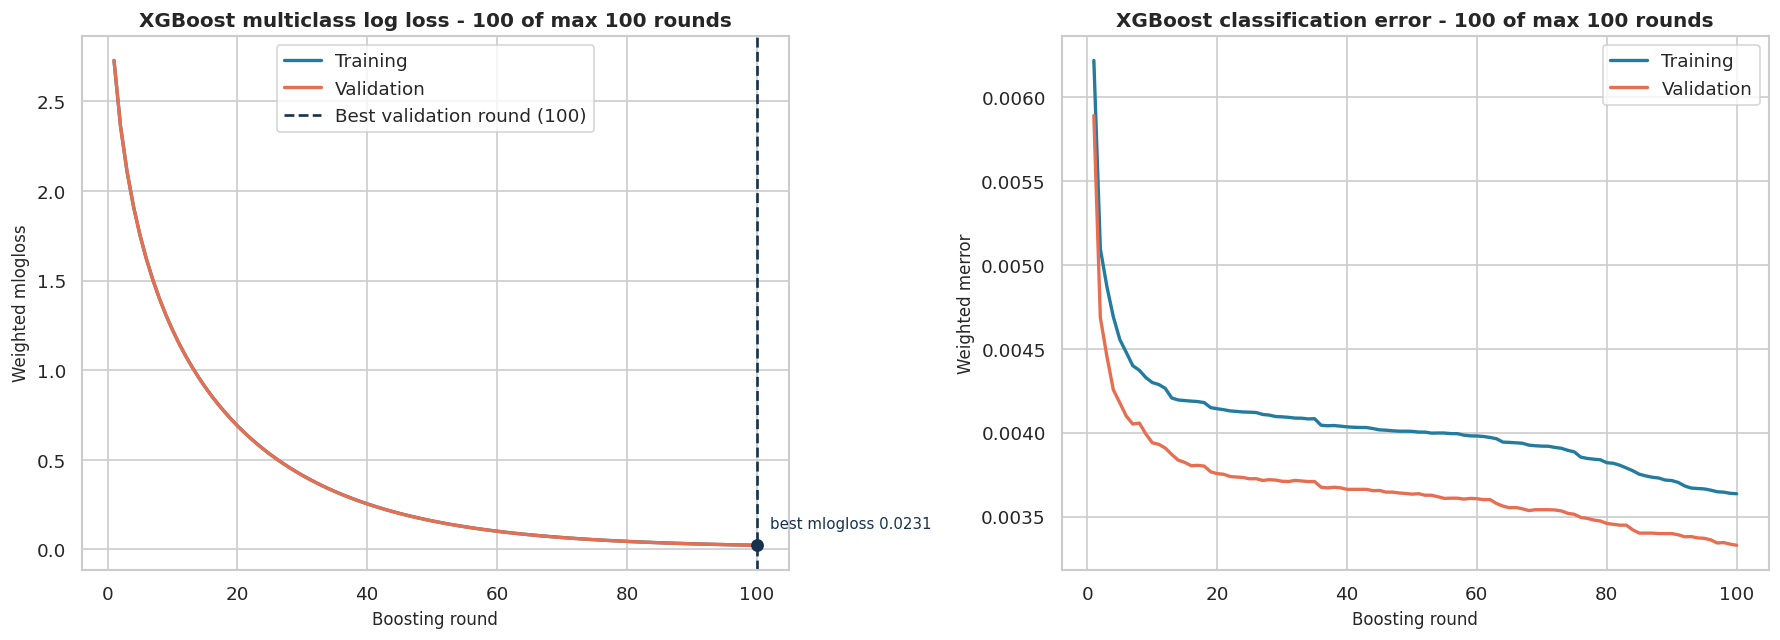

No early stopping: all 100 configured boosting rounds were executed.


In [49]:
xgb_history = xgb_model.evals_result()
# The x-axis follows the recorded history, not XGBOOST_ROUNDS, so the curves are correct
# whether early stopping fired or the full configured budget was executed.
xgb_curve_length = len(xgb_history["validation_1"]["mlogloss"])
rounds = np.arange(1, xgb_curve_length + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for split_key, label, color in [
    ("validation_0", "Training", PALETTE["blue"]),
    ("validation_1", "Validation", PALETTE["red"]),
]:
    axes[0].plot(
        rounds, xgb_history[split_key]["mlogloss"][:xgb_curve_length], label=label, color=color, linewidth=2
    )
    axes[1].plot(
        rounds, xgb_history[split_key]["merror"][:xgb_curve_length], label=label, color=color, linewidth=2
    )

# Mark the round selected by validation early stopping.
axes[0].axvline(
    xgb_best_round,
    color=PALETTE["navy"],
    linestyle="--",
    linewidth=1.6,
    label=f"Best validation round ({xgb_best_round})",
)
axes[0].scatter([xgb_best_round], [xgb_best_score], color=PALETTE["navy"], s=45, zorder=5)
axes[0].annotate(
    f"best mlogloss {xgb_best_score:.4f}",
    xy=(xgb_best_round, xgb_best_score),
    xytext=(8, 10),
    textcoords="offset points",
    fontsize=9,
    color=PALETTE["navy"],
)

axes[0].set_title(f"XGBoost multiclass log loss - {xgb_curve_length} of max {XGBOOST_ROUNDS} rounds")
axes[0].set_xlabel("Boosting round")
axes[0].set_ylabel("Weighted mlogloss")
axes[1].set_title(f"XGBoost classification error - {xgb_curve_length} of max {XGBOOST_ROUNDS} rounds")
axes[1].set_xlabel("Boosting round")
axes[1].set_ylabel("Weighted merror")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

if xgb_early_stopped:
    print(
        f"Early stopping triggered: validation mlogloss did not improve for "
        f"{XGBOOST_EARLY_STOPPING_ROUNDS} consecutive rounds after round {xgb_best_round}."
    )
else:
    print(f"No early stopping: all {XGBOOST_ROUNDS} configured boosting rounds were executed.")

## 11. Validation-based model selection

Both fitted strategies are evaluated on the training and validation partitions. The winner is selected by validation macro F1, with macro one-vs-rest ROC AUC and accuracy used only as tie-breakers.

| Metric | Interpretation |
|---|---|
| Accuracy | Overall proportion of correct predictions |
| Balanced accuracy | Mean recall across pathologies |
| Macro precision | Mean class-wise positive predictive value |
| Macro sensitivity | Mean class-wise recall |
| Macro specificity | Mean one-vs-rest true-negative rate |
| Macro F1 | Equal-weight harmonic mean of precision and recall; primary selection metric |
| Weighted F1 | Class-wise F1 weighted by support |
| Log loss | Quality and confidence of the complete probability distribution |
| Macro ROC AUC | Equal-weight one-vs-rest ranking performance |
| Top-3 / Top-5 accuracy | Whether the true pathology appears in the ranked differential |

The test set is not consulted during this decision.

In [50]:
def aligned_predict_proba(model, X, n_classes: int) -> np.ndarray:
    probabilities = np.asarray(model.predict_proba(X))
    model_classes = np.asarray(model.classes_, dtype=int)
    if probabilities.ndim != 2:
        raise ValueError(f"Unsupported probability shape: {probabilities.shape}")
    aligned = np.zeros((probabilities.shape[0], n_classes), dtype=np.float32)
    aligned[:, model_classes] = probabilities.astype(np.float32, copy=False)
    row_sums = aligned.sum(axis=1)
    if not np.allclose(row_sums, 1.0, atol=1e-4):
        raise ValueError("Predicted class probabilities do not sum to one.")
    return aligned


def macro_specificity(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> float:
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    total = cm.sum()
    tp = np.diag(cm)
    fn = cm.sum(axis=1) - tp
    fp = cm.sum(axis=0) - tp
    tn = total - tp - fn - fp
    denominators = tn + fp
    valid = denominators > 0
    return float(np.mean(tn[valid] / denominators[valid]))


def evaluate_probabilistic_classifier(model, X, y_true, n_classes: int, return_predictions=False):
    probabilities = aligned_predict_proba(model, X, n_classes)
    predictions = probabilities.argmax(axis=1)
    labels = np.arange(n_classes)
    metrics = {
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced accuracy": balanced_accuracy_score(y_true, predictions),
        "Precision (macro)": precision_score(y_true, predictions, average="macro", zero_division=0),
        "Sensitivity / Recall (macro)": recall_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "Specificity (macro OvR)": macro_specificity(y_true, predictions, n_classes),
        "F1 (macro)": f1_score(y_true, predictions, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_true, predictions, average="weighted", zero_division=0),
        "Log loss": log_loss(y_true, probabilities, labels=labels),
        "ROC AUC (macro OvR)": roc_auc_score(
            y_true,
            probabilities,
            labels=labels,
            multi_class="ovr",
            average="macro",
        ),
        "Top-3 accuracy": top_k_accuracy_score(y_true, probabilities, k=3, labels=labels),
        "Top-5 accuracy": top_k_accuracy_score(y_true, probabilities, k=5, labels=labels),
    }
    if return_predictions:
        return metrics, predictions, probabilities
    return metrics


serving_models = {
    "FLAML AutoML": flaml_model,
    XGB_MODEL_LABEL: xgb_model,
}

In [51]:
train_metrics = {}
validation_metrics = {}

for model_name, model in serving_models.items():
    print(f"Evaluating {model_name} on training data...")
    train_metrics[model_name] = evaluate_probabilistic_classifier(
        model, X_train, y_train, N_CLASSES
    )
    print(f"Evaluating {model_name} on validation data...")
    validation_metrics[model_name] = evaluate_probabilistic_classifier(
        model, X_validation, y_validation, N_CLASSES
    )

train_comparison = pd.DataFrame(train_metrics).T
validation_comparison = pd.DataFrame(validation_metrics).T

display(Markdown("### Training metrics"))
display(train_comparison.style.format("{:.4f}").highlight_max(axis=0, color="#D9F2E6"))
display(Markdown("### Validation metrics - used for model selection"))
display(validation_comparison.style.format("{:.4f}").highlight_max(axis=0, color="#D9F2E6"))

Evaluating FLAML AutoML on training data...
Evaluating FLAML AutoML on validation data...
Evaluating XGBoost (100/100 rounds) on training data...
Evaluating XGBoost (100/100 rounds) on validation data...


### Training metrics

,Accuracy,Balanced accuracy,Precision (macro),Sensitivity / Recall (macro),Specificity (macro OvR),F1 (macro),F1 (weighted),Log loss,ROC AUC (macro OvR),Top-3 accuracy,Top-5 accuracy
FLAML AutoML,0.9975,0.9968,0.9974,0.9968,0.9999,0.9970,0.9974,0.0072,1.0000,1.0000,1.0000
XGBoost (100/100 rounds),0.9972,0.9964,0.9973,0.9964,0.9999,0.9966,0.9971,0.0217,1.0000,1.0000,1.0000


### Validation metrics - used for model selection

,Accuracy,Balanced accuracy,Precision (macro),Sensitivity / Recall (macro),Specificity (macro OvR),F1 (macro),F1 (weighted),Log loss,ROC AUC (macro OvR),Top-3 accuracy,Top-5 accuracy
FLAML AutoML,0.9976,0.9969,0.9976,0.9969,1.0000,0.9971,0.9976,0.0073,1.0000,1.0000,1.0000
XGBoost (100/100 rounds),0.9975,0.9966,0.9970,0.9966,0.9999,0.9966,0.9975,0.0215,1.0000,1.0000,1.0000


In [52]:
# Selection is fixed before any test-set predictions are computed.
selection_order = validation_comparison.sort_values(
    by=["F1 (macro)", "ROC AUC (macro OvR)", "Accuracy"],
    ascending=False,
)
selected_model_name = selection_order.index[0]
selected_model = serving_models[selected_model_name]

display(
    Markdown(
        f"### Selected strategy: **{selected_model_name}**  \n"
        f"Validation macro F1: **{validation_comparison.loc[selected_model_name, 'F1 (macro)']:.4f}**  \n"
        "The test set has not been used for this decision."
    )
)

### Selected strategy: **FLAML AutoML**  
Validation macro F1: **0.9971**  
The test set has not been used for this decision.

## 12. Final test evaluation

Once the winning strategy has been fixed on validation macro F1, both models are evaluated on the untouched 10% test partition. Reporting both strategies supports comparison, but the winner is not changed using test performance.

The result table is complemented by a grouped metric chart, row-normalised confusion matrices, multiclass ROC curves and per-pathology precision, sensitivity and F1. Together these views expose errors that would be hidden by a single aggregate score.

The grouped bar chart below is the direct graphical comparison between FLAML and standalone XGBoost on the final test metrics. The subsequent confusion matrices and ROC curves provide two additional side-by-side comparisons.

Final test evaluation: FLAML AutoML
Final test evaluation: XGBoost (100/100 rounds)


,Accuracy,Balanced accuracy,Precision (macro),Sensitivity / Recall (macro),Specificity (macro OvR),F1 (macro),F1 (weighted),Log loss,ROC AUC (macro OvR),Top-3 accuracy,Top-5 accuracy
FLAML AutoML,0.9977,0.9969,0.9977,0.9969,1.0000,0.9972,0.9977,0.0073,1.0000,1.0000,1.0000
XGBoost (100/100 rounds),0.9974,0.9965,0.9970,0.9965,0.9999,0.9966,0.9974,0.0216,1.0000,1.0000,1.0000


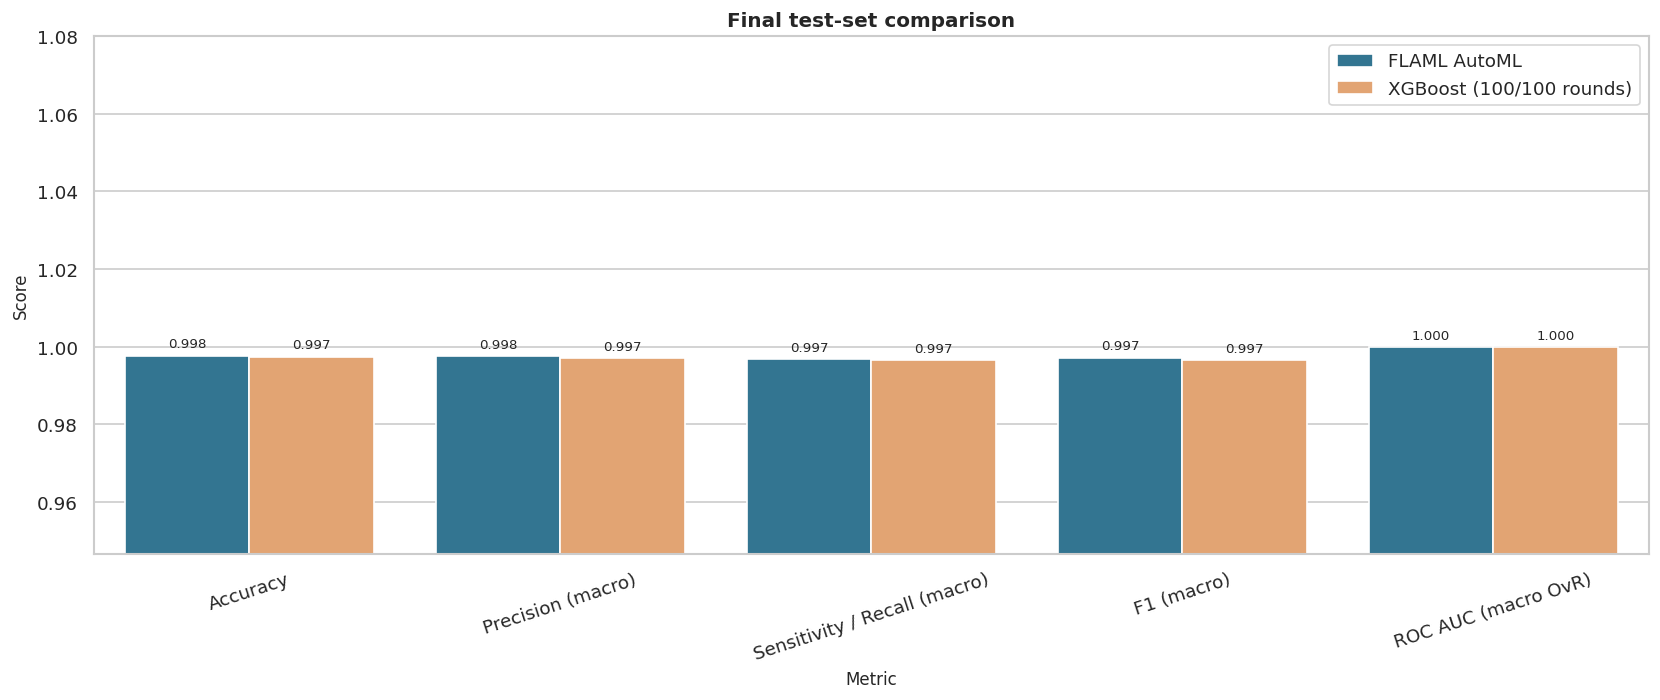

In [53]:
test_outputs = {}
test_metrics = {}

for model_name, model in serving_models.items():
    print(f"Final test evaluation: {model_name}")
    metrics, predictions, probabilities = evaluate_probabilistic_classifier(
        model, X_test, y_test, N_CLASSES, return_predictions=True
    )
    test_metrics[model_name] = metrics
    test_outputs[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities,
    }

test_comparison = pd.DataFrame(test_metrics).T
display(test_comparison.style.format("{:.4f}").highlight_max(axis=0, color="#D9F2E6"))

metric_plot_columns = [
    "Accuracy",
    "Precision (macro)",
    "Sensitivity / Recall (macro)",
    "F1 (macro)",
    "ROC AUC (macro OvR)",
]
comparison_long = (
    test_comparison[metric_plot_columns]
    .reset_index(names="Model")
    .melt(id_vars="Model", var_name="Metric", value_name="Score")
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=comparison_long, x="Metric", y="Score", hue="Model", palette=[PALETTE["blue"], PALETTE["orange"]], ax=ax)
ax.set_ylim(max(0, comparison_long["Score"].min() - 0.05), 1.08)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
ax.set_title("Final test-set comparison")
ax.tick_params(axis="x", rotation=18)
ax.legend(title="")
plt.tight_layout()
plt.show()

### 12.1 Confusion matrices

Rows represent true pathologies and columns represent predictions. Row normalisation expresses each cell as a proportion of its true class, so rare and common pathologies remain comparable. With 49 classes, cell annotations would be unreadable; axis labels and the shared colour scale are retained instead.

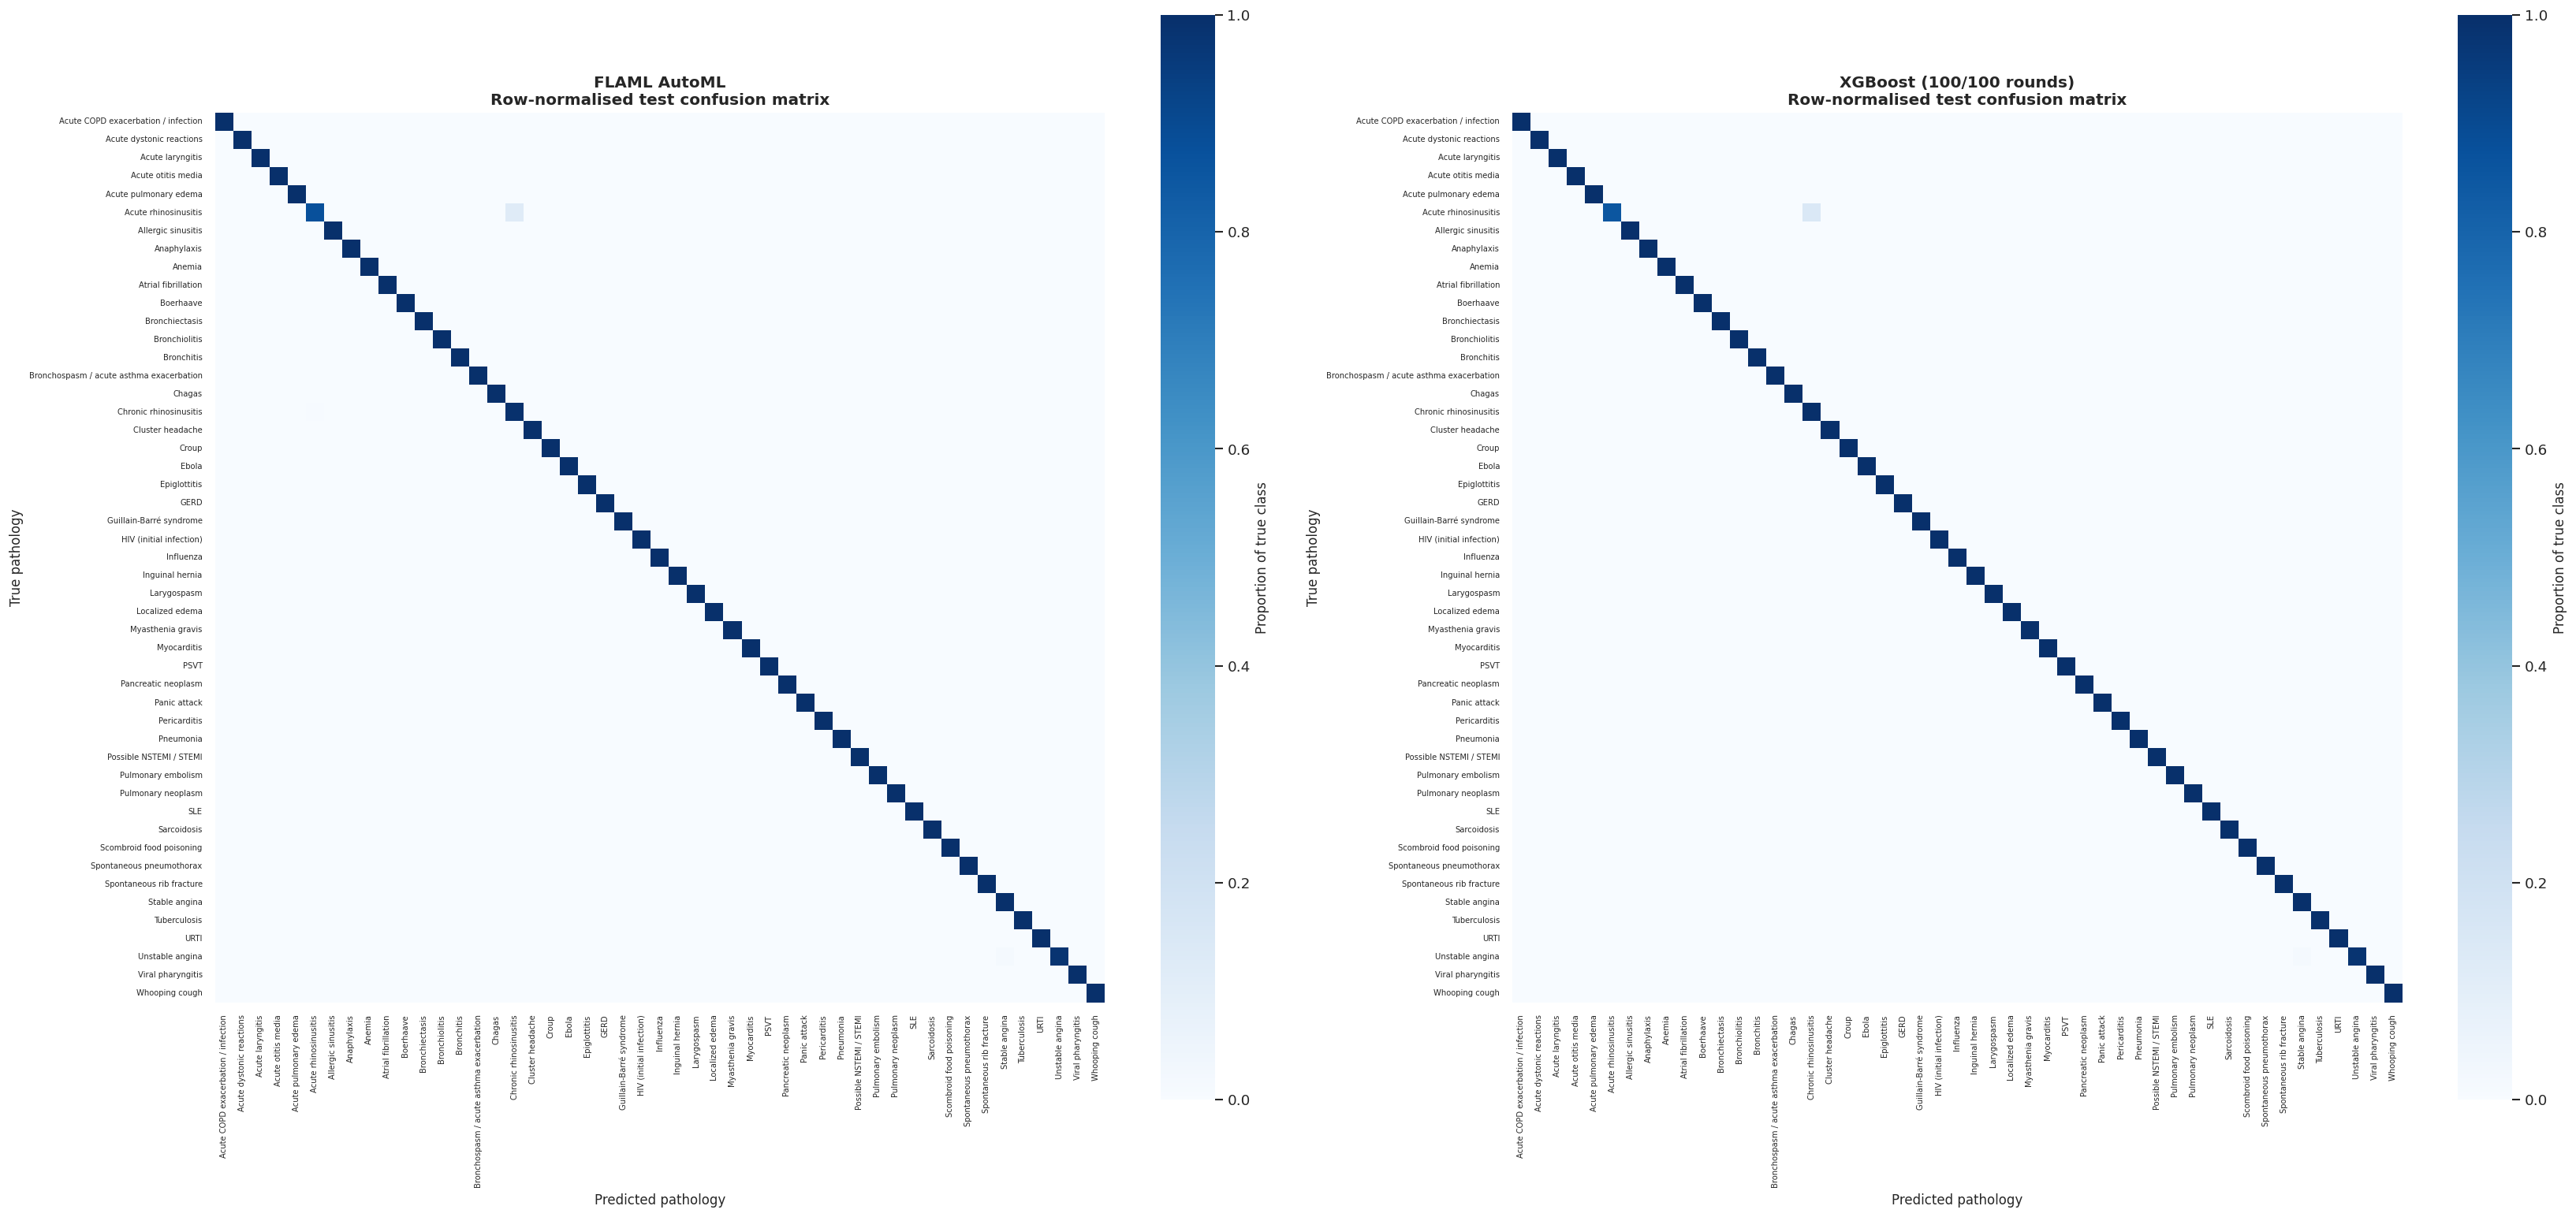

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(28, 13))
for ax, (model_name, output) in zip(axes, test_outputs.items()):
    cm_normalized = confusion_matrix(
        y_test,
        output["predictions"],
        labels=np.arange(N_CLASSES),
        normalize="true",
    )
    sns.heatmap(
        cm_normalized,
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Proportion of true class"},
        ax=ax,
    )
    ax.set_title(f"{model_name}\nRow-normalised test confusion matrix")
    ax.set_xlabel("Predicted pathology")
    ax.set_ylabel("True pathology")
    ax.tick_params(axis="x", labelrotation=90, labelsize=6)
    ax.tick_params(axis="y", labelrotation=0, labelsize=6)

plt.tight_layout()
plt.show()

### 12.2 Multiclass ROC curves

Each pathology is evaluated one-vs-rest. The micro-average pools all class decisions and is influenced by frequent classes; the macro-average gives every pathology equal weight. Both curves are shown, while macro ROC AUC remains the primary AUC summary for this imbalanced task.

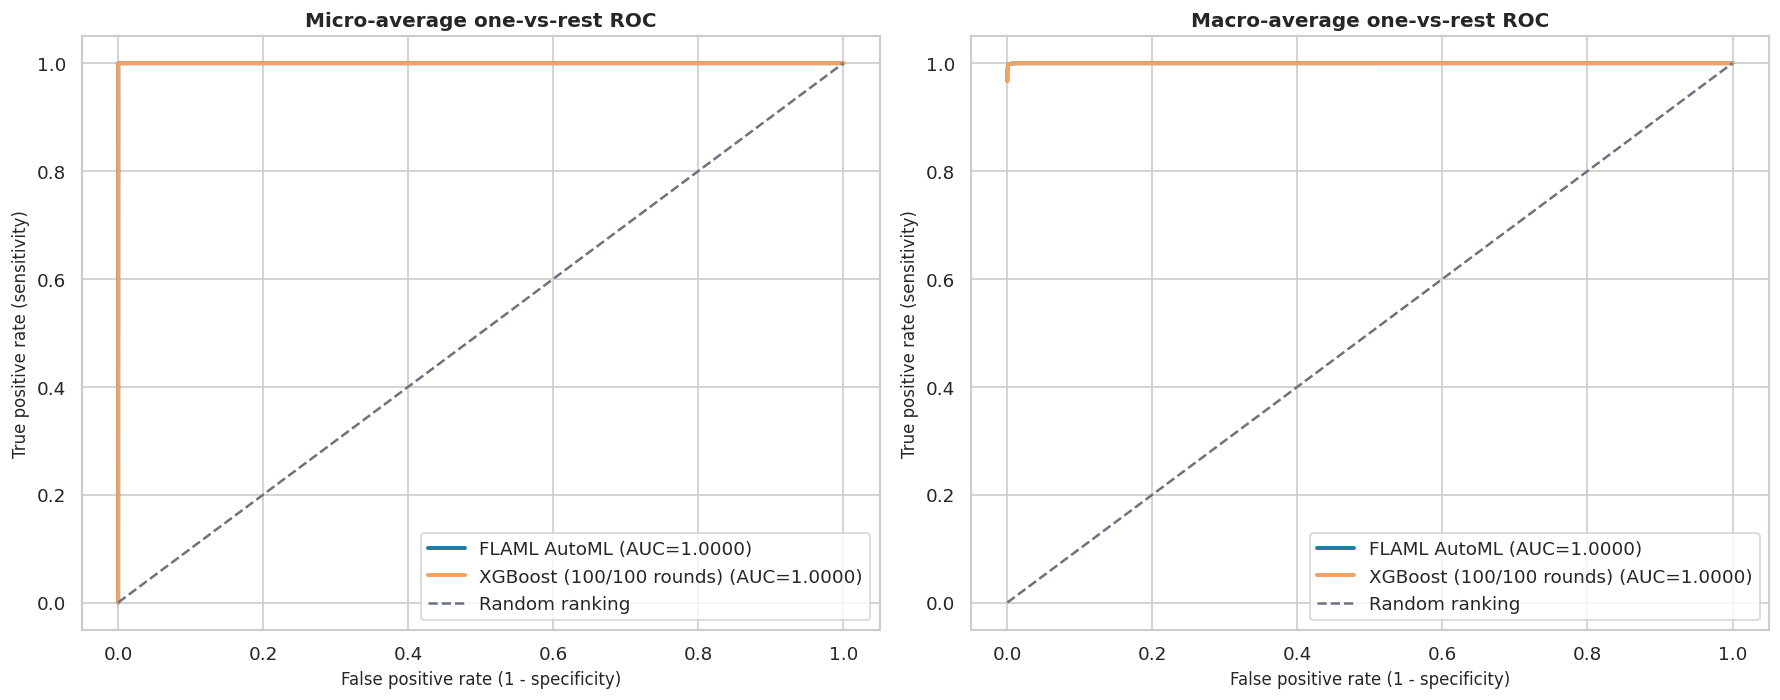

In [55]:
y_test_binary = label_binarize(y_test, classes=np.arange(N_CLASSES))
curve_colors = {
    "FLAML AutoML": PALETTE["blue"],
    XGB_MODEL_LABEL: PALETTE["orange"],
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, average_name in zip(axes, ["micro", "macro"]):
    for model_name, output in test_outputs.items():
        probabilities = output["probabilities"]
        if average_name == "micro":
            fpr, tpr, _ = roc_curve(y_test_binary.ravel(), probabilities.ravel())
            curve_auc = auc(fpr, tpr)
        else:
            class_fpr = {}
            class_tpr = {}
            for class_index in range(N_CLASSES):
                class_fpr[class_index], class_tpr[class_index], _ = roc_curve(
                    y_test_binary[:, class_index], probabilities[:, class_index]
                )
            all_fpr = np.unique(np.concatenate([class_fpr[i] for i in range(N_CLASSES)]))
            mean_tpr = np.zeros_like(all_fpr)
            for class_index in range(N_CLASSES):
                mean_tpr += np.interp(all_fpr, class_fpr[class_index], class_tpr[class_index])
            mean_tpr /= N_CLASSES
            fpr, tpr = all_fpr, mean_tpr
            curve_auc = auc(fpr, tpr)

        ax.plot(
            fpr,
            tpr,
            linewidth=2.4,
            color=curve_colors[model_name],
            label=f"{model_name} (AUC={curve_auc:.4f})",
        )

    ax.plot([0, 1], [0, 1], linestyle="--", color=PALETTE["grey"], label="Random ranking")
    ax.set_title(f"{average_name.capitalize()}-average one-vs-rest ROC")
    ax.set_xlabel("False positive rate (1 - specificity)")
    ax.set_ylabel("True positive rate (sensitivity)")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

### 12.3 Per-pathology performance

Aggregate metrics can conceal a weak minority class. Classification reports are therefore sorted by sensitivity, placing the most frequently missed pathologies first. These reports are diagnostic only and do not alter the model choice already fixed on the validation set.

In [56]:
per_class_reports = {}
for model_name, output in test_outputs.items():
    report = classification_report(
        y_test,
        output["predictions"],
        labels=np.arange(N_CLASSES),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    report_frame = pd.DataFrame(report).T.loc[class_names, ["precision", "recall", "f1-score", "support"]]
    report_frame = report_frame.rename(columns={"recall": "sensitivity", "f1-score": "f1"})
    report_frame = report_frame.sort_values("sensitivity", ascending=True)
    per_class_reports[model_name] = report_frame
    display(Markdown(f"#### {model_name} - per-pathology test report"))
    display(report_frame.style.format({"precision": "{:.4f}", "sensitivity": "{:.4f}", "f1": "{:.4f}", "support": "{:.0f}"}))

#### FLAML AutoML - per-pathology test report

,precision,sensitivity,f1,support
Acute rhinosinusitis,0.9902,0.8767,0.9300,1727
Unstable angina,1.0000,0.9844,0.9921,2687
Chronic rhinosinusitis,0.9240,0.9942,0.9578,2604
Viral pharyngitis,0.9997,0.9969,0.9983,7822
Croup,1.0000,0.9971,0.9986,346
Acute laryngitis,0.9923,0.9993,0.9958,3075
Myasthenia gravis,1.0000,0.9996,0.9998,2294
Acute otitis media,1.0000,1.0000,1.0000,3291
Anemia,1.0000,1.0000,1.0000,6441
Atrial fibrillation,1.0000,1.0000,1.0000,2648


#### XGBoost (100/100 rounds) - per-pathology test report

,precision,sensitivity,f1,support
Acute rhinosinusitis,0.9993,0.8523,0.9200,1727
Unstable angina,1.0000,0.9844,0.9921,2687
Viral pharyngitis,0.9995,0.9971,0.9983,7822
Acute laryngitis,0.9926,0.9984,0.9955,3075
Chronic rhinosinusitis,0.9108,0.9996,0.9531,2604
Pericarditis,1.0000,0.9997,0.9998,2891
Pneumonia,1.0000,0.9997,0.9998,3279
Acute otitis media,1.0000,0.9997,0.9998,3291
Bronchitis,0.9997,0.9997,0.9997,3354
Anemia,1.0000,1.0000,1.0000,6441


## 13. Explainability and generalisation diagnostics

The training-to-test gaps in accuracy and macro F1 provide a direct overfitting diagnostic. A large positive gap indicates that performance on the training distribution does not transfer to unseen rows.

For tree-based winners, global feature importance identifies the encoded variables most often used to improve tree splits. This is a model-level summary: it does not establish causality and must not be presented as a patient-specific clinical explanation.

,Training accuracy,Test accuracy,Accuracy gap,Training macro F1,Test macro F1,Macro F1 gap
FLAML AutoML,0.9975,0.9977,-0.0002,0.9970,0.9972,-0.0002
XGBoost (100/100 rounds),0.9972,0.9974,-0.0003,0.9966,0.9966,0.0000


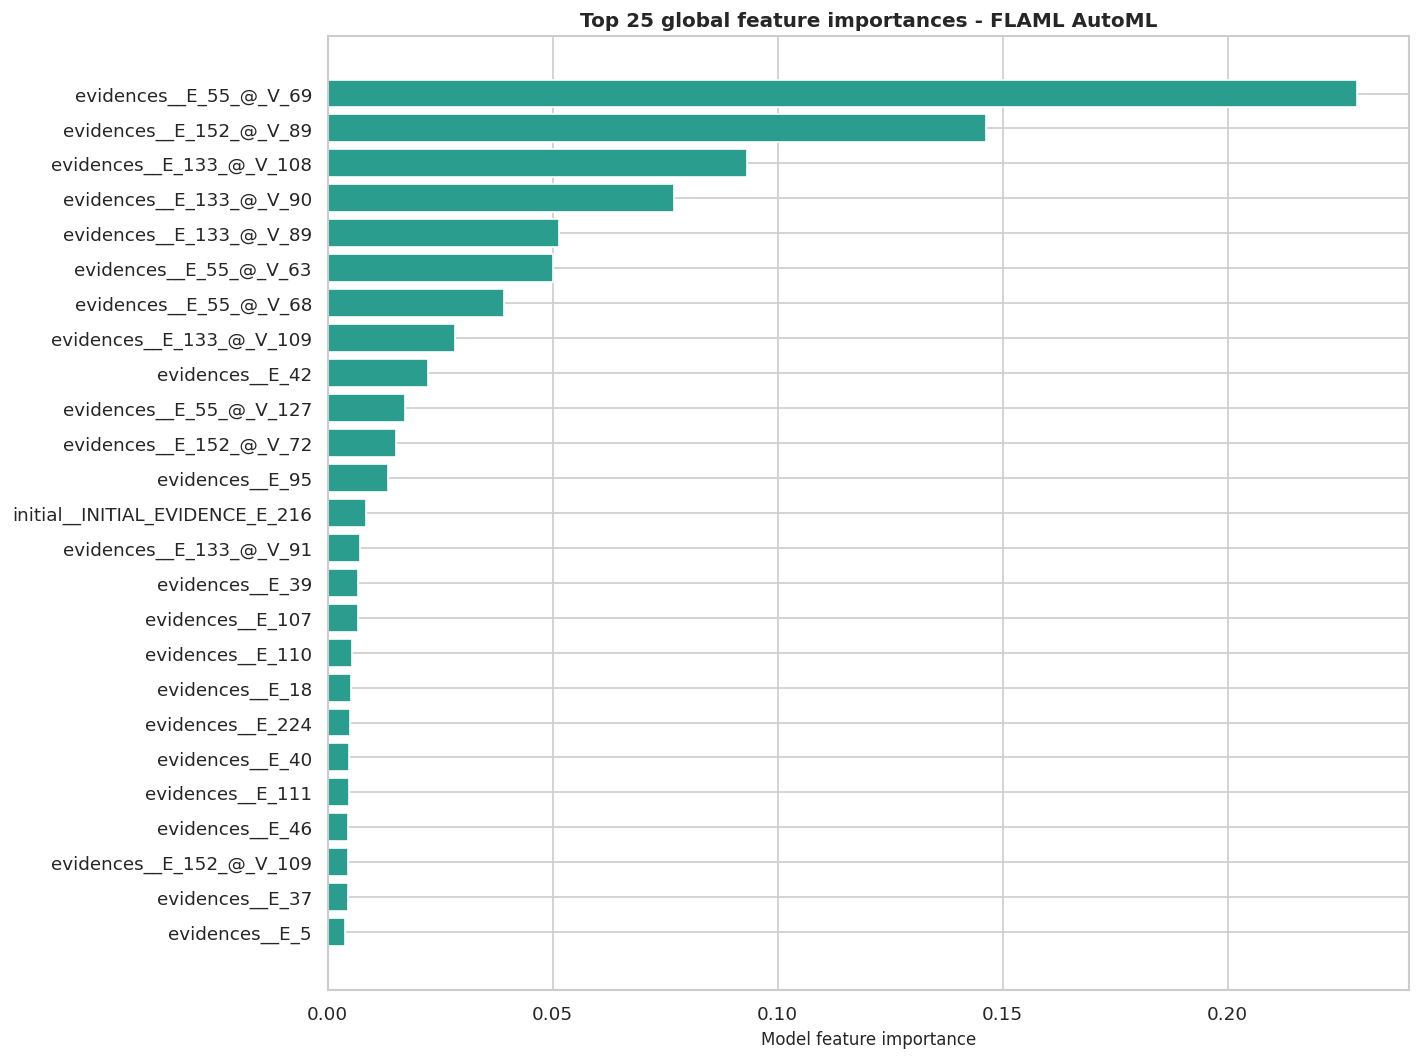

In [57]:
generalisation_gap = pd.DataFrame(index=serving_models)
generalisation_gap["Training accuracy"] = [train_metrics[name]["Accuracy"] for name in serving_models]
generalisation_gap["Test accuracy"] = [test_metrics[name]["Accuracy"] for name in serving_models]
generalisation_gap["Accuracy gap"] = generalisation_gap["Training accuracy"] - generalisation_gap["Test accuracy"]
generalisation_gap["Training macro F1"] = [train_metrics[name]["F1 (macro)"] for name in serving_models]
generalisation_gap["Test macro F1"] = [test_metrics[name]["F1 (macro)"] for name in serving_models]
generalisation_gap["Macro F1 gap"] = generalisation_gap["Training macro F1"] - generalisation_gap["Test macro F1"]
display(generalisation_gap.style.format("{:.4f}"))

if hasattr(selected_model, "feature_importances_"):
    importances = np.asarray(selected_model.feature_importances_, dtype=float)
    if len(importances) != len(feature_names):
        raise ValueError(
            f"Feature-importance length {len(importances)} does not match preprocessor output {len(feature_names)}."
        )
    importance_table = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(25)
        .sort_values("importance")
    )
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.barh(importance_table["feature"], importance_table["importance"], color=PALETTE["teal"])
    ax.set_title(f"Top 25 global feature importances - {selected_model_name}")
    ax.set_xlabel("Model feature importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    importance_table = pd.DataFrame()
    print(f"{selected_model_name} does not expose tree feature_importances_; no substitute method is added outside scope.")

## 14. Model export and API compatibility

The selected estimator, fitted preprocessor and label encoder are exported separately because the FastAPI service applies the same three-stage inference path used in the notebook:

1. transform the four-column request frame;
2. compute class probabilities;
3. map probability columns back to pathology names.

If the selected XGBoost estimator was trained on GPU, a deep-copied deployment version is switched to CPU inference and stripped of training-only callback settings. A probability-equivalence assertion confirms that the portable copy produces the same output before serialization.

The final reload test reads every artifact, processes raw test rows and verifies probability shape, class order and row-wise probability sums. The generated files are `best_model.pkl`, `preprocessor.pkl`, `label_encoder.pkl` and `model_metrics.json`.

In [58]:
ARTIFACT_DIR = WORKING_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

artifact_paths = {
    "best_model.pkl": ARTIFACT_DIR / "best_model.pkl",
    "preprocessor.pkl": ARTIFACT_DIR / "preprocessor.pkl",
    "label_encoder.pkl": ARTIFACT_DIR / "label_encoder.pkl",
    "model_metrics.json": ARTIFACT_DIR / "model_metrics.json",
}

# Probability columns must correspond to LabelEncoder indices 0..N_CLASSES-1.
assert np.array_equal(np.asarray(selected_model.classes_, dtype=int), np.arange(N_CLASSES))

deployment_model = copy.deepcopy(selected_model)
if type(deployment_model).__module__.startswith("xgboost"):
    # Inference-only copy. A list-valued `eval_metric` cannot be re-pushed into an already
    # fitted booster (xgboost 2.1 raises "Unknown metric function"), and the training-time
    # early-stopping callback is meaningless at serving time, so both are cleared here.
    deployment_params = deployment_model.get_params()
    portable_params = {"device": "cpu"}
    if isinstance(deployment_params.get("eval_metric"), (list, tuple)):
        portable_params["eval_metric"] = None
    if deployment_params.get("callbacks"):
        portable_params["callbacks"] = None
    deployment_model.set_params(**portable_params)

portable_check_X = X_test[:256]
reference_probabilities = aligned_predict_proba(selected_model, portable_check_X, N_CLASSES)
deployment_probabilities = aligned_predict_proba(deployment_model, portable_check_X, N_CLASSES)
assert np.allclose(reference_probabilities, deployment_probabilities, atol=1e-6)
assert np.array_equal(np.asarray(deployment_model.classes_, dtype=int), np.arange(N_CLASSES))

joblib.dump(deployment_model, artifact_paths["best_model.pkl"], compress=3)
joblib.dump(preprocessor, artifact_paths["preprocessor.pkl"], compress=3)
joblib.dump(label_encoder, artifact_paths["label_encoder.pkl"], compress=3)


def records_from_metric_frame(frame: pd.DataFrame) -> list[dict]:
    records = []
    for model_name, row in frame.iterrows():
        record = {"model": str(model_name)}
        record.update({str(key): float(value) for key, value in row.items()})
        records.append(record)
    return records


metrics_payload = {
    "schema_version": 1,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": {
        "name": "DDXPlus English v2",
        "kaggle_ref": "deveddu17xx/ddxplus-english-v2",
        "usable_rows_before_augmentation": int(ORIGINAL_USABLE_ROWS),
        "training_rows_after_augmentation": int(len(train_frame)),
        "augmentation_rows_added": int(augmentation_rows_added),
        "n_classes": int(N_CLASSES),
        "n_transformed_features": int(X_train.shape[1]),
        "quick_run": bool(QUICK_RUN),
    },
    "problem": {
        "task": "single-label multiclass classification",
        "target": TARGET_COLUMN,
        "runtime_features": FEATURE_COLUMNS,
        "forbidden_leakage_features": ["PATHOLOGY", "DIFFERENTIAL_DIAGNOSIS"],
        "selection_metric": "validation macro F1",
    },
    "split": {
        "strategy": "shuffled stratified holdout",
        "random_state": RANDOM_STATE,
        "train_rows_before_augmentation": int(training_rows_before_augmentation),
        "validation_rows": int(len(validation_frame)),
        "test_rows": int(len(test_frame)),
        "train_fraction": float(training_rows_before_augmentation / ORIGINAL_USABLE_ROWS),
        "validation_fraction": float(len(validation_frame) / ORIGINAL_USABLE_ROWS),
        "test_fraction": float(len(test_frame) / ORIGINAL_USABLE_ROWS),
    },
    "training": {
        "flaml_max_iter": FLAML_ITERATIONS,
        "flaml_max_trials": int(FLAML_ITERATIONS),
        "flaml_recorded_trials": int(flaml_logged_trials),
        "flaml_actual_logged_trials": int(flaml_logged_trials),
        "flaml_native_early_stop": bool(FLAML_NATIVE_EARLY_STOP),
        "flaml_native_early_stop_kind": "boolean convergence-based; no numeric trial patience",
        "flaml_auto_augment": bool(FLAML_AUTO_AUGMENT),
        "flaml_stopped_before_trial_cap": bool(flaml_stopped_early),
        "flaml_best_estimator": str(automl.best_estimator),
        "flaml_best_config": automl.best_config,
        "flaml_best_validation_macro_f1": float(1 - automl.best_loss),
        "flaml_search_seconds": float(flaml_search_seconds),
        "flaml_full_refit_seconds": float(flaml_refit_seconds),
        "xgboost_rounds": XGBOOST_ROUNDS,
        "xgboost_max_rounds": int(XGBOOST_ROUNDS),
        "xgboost_executed_rounds": int(xgb_executed_rounds),
        "xgboost_best_iteration": int(xgb_best_iteration),
        "xgboost_best_round": int(xgb_best_round),
        "xgboost_best_score_validation_mlogloss": float(xgb_best_score),
        "xgboost_early_stopping_rounds": int(XGBOOST_EARLY_STOPPING_ROUNDS),
        "xgboost_early_stopped": bool(xgb_early_stopped),
        "xgboost_early_stopping_monitor": "validation_1 / mlogloss (20% validation split)",
        "xgboost_learning_rate": 0.05,
        "xgboost_fit_seconds": float(xgb_fit_seconds),
        "xgboost_device": str(xgb_fit_device),
        "xgboost_configured_device": str(XGB_DEVICE),
        "data_augmentation": {
            "method": "training-only secondary-evidence masking",
            "target_quantile": float(AUGMENTATION_TARGET_QUANTILE),
            "maximum_rows_per_class": int(AUGMENTATION_MAX_PER_CLASS),
            "rows_added": int(augmentation_rows_added),
        },
        "class_weighting": "balanced weights computed from augmented training labels",
    },
    "selection": {
        "selected_model": selected_model_name,
        "selected_model_class": f"{type(deployment_model).__module__}.{type(deployment_model).__name__}",
        "deployment_inference_device": "cpu",
        "validation_results": records_from_metric_frame(validation_comparison),
    },
    "train_results": records_from_metric_frame(train_comparison),
    "test_results": records_from_metric_frame(test_comparison),
    "per_class_test_results": {
        model_name: [
            {
                "pathology": str(pathology),
                "precision": float(row["precision"]),
                "sensitivity": float(row["sensitivity"]),
                "f1": float(row["f1"]),
                "support": int(row["support"]),
            }
            for pathology, row in report.iterrows()
        ]
        for model_name, report in per_class_reports.items()
    },
    "versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
        "joblib": joblib.__version__,
    },
    "disclaimer": "Educational decision-support prototype trained on synthetic patients; not a medical diagnosis.",
}


def to_builtin(value):
    # Recursively convert NumPy/scalar objects into JSON-serialisable Python values.
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(item) for item in value]
    return value


with artifact_paths["model_metrics.json"].open("w", encoding="utf-8") as file:
    json.dump(to_builtin(metrics_payload), file, indent=2, ensure_ascii=False)

artifact_manifest = pd.DataFrame(
    [
        {
            "file": name,
            "path": str(path),
            "size_mb": path.stat().st_size / 2**20,
        }
        for name, path in artifact_paths.items()
    ]
)
display(artifact_manifest.style.format({"size_mb": "{:.3f}"}))

,file,path,size_mb
0,best_model.pkl,/kaggle/working/artifacts/best_model.pkl,3.981
1,preprocessor.pkl,/kaggle/working/artifacts/preprocessor.pkl,0.004
2,label_encoder.pkl,/kaggle/working/artifacts/label_encoder.pkl,0.001
3,model_metrics.json,/kaggle/working/artifacts/model_metrics.json,0.021


In [59]:
# Reload every artifact and execute the same raw-frame -> probabilities path used by the API.
reloaded_model = joblib.load(artifact_paths["best_model.pkl"])
reloaded_preprocessor = joblib.load(artifact_paths["preprocessor.pkl"])
reloaded_label_encoder = joblib.load(artifact_paths["label_encoder.pkl"])

api_smoke_frame = test_frame[FEATURE_COLUMNS].head(128).copy()
api_smoke_matrix = reloaded_preprocessor.transform(api_smoke_frame)
api_smoke_probabilities = aligned_predict_proba(reloaded_model, api_smoke_matrix, N_CLASSES)
api_smoke_top_indices = np.argsort(api_smoke_probabilities[0])[::-1][:5]
api_smoke_top5 = pd.DataFrame(
    {
        "diagnosis": reloaded_label_encoder.inverse_transform(api_smoke_top_indices),
        "probability": api_smoke_probabilities[0, api_smoke_top_indices],
    }
)

assert api_smoke_matrix.shape[1] == X_train.shape[1]
assert api_smoke_probabilities.shape == (len(api_smoke_frame), N_CLASSES)
assert np.array_equal(reloaded_label_encoder.classes_, label_encoder.classes_)
assert np.allclose(api_smoke_probabilities.sum(axis=1), 1.0, atol=1e-4)

display(api_smoke_top5.style.format({"probability": "{:.4%}"}))
print("Artifact reload and API-shape smoke test: PASSED")

archive_base = WORKING_ROOT / "ddxplus_model_artifacts"
archive_path = Path(shutil.make_archive(str(archive_base), "zip", root_dir=ARTIFACT_DIR))
print(f"Created archive: {archive_path}")

display(Markdown("### Download individual artifacts"))
for path in artifact_paths.values():
    display(FileLink(str(path)))
display(Markdown("### Download all four artifacts as one ZIP archive"))
display(FileLink(str(archive_path)))

,diagnosis,probability
0,Anaphylaxis,99.9913%
1,Larygospasm,0.0076%
2,Epiglottitis,0.0006%
3,Influenza,0.0001%
4,Scombroid food poisoning,0.0001%


Artifact reload and API-shape smoke test: PASSED
Created archive: /kaggle/working/ddxplus_model_artifacts.zip


### Download individual artifacts

/kaggle/working/artifacts/best_model.pkl

/kaggle/working/artifacts/preprocessor.pkl

/kaggle/working/artifacts/label_encoder.pkl

/kaggle/working/artifacts/model_metrics.json

### Download all four artifacts as one ZIP archive

/kaggle/working/ddxplus_model_artifacts.zip

## 15. Evidence-based conclusion

The next cell builds the conclusion directly from the validation and test tables. This avoids manually transcribing metric values and ensures that the selected strategy, weakest classes, generalisation gap and training budgets remain consistent with the executed experiment.

In [60]:
selected_validation = validation_comparison.loc[selected_model_name]
selected_test = test_comparison.loc[selected_model_name]
selected_gap = generalisation_gap.loc[selected_model_name]

lowest_recall_rows = per_class_reports[selected_model_name].head(3)
lowest_recall_text = ", ".join(
    f"{pathology} ({row['sensitivity']:.3f})"
    for pathology, row in lowest_recall_rows.iterrows()
)

display(
    Markdown(
        f"""
### Results

**{selected_model_name}** was selected before test evaluation because it achieved the highest validation macro F1 (**{selected_validation['F1 (macro)']:.4f}**). On the final 10% test split it obtained:

- accuracy: **{selected_test['Accuracy']:.4f}**;
- balanced accuracy: **{selected_test['Balanced accuracy']:.4f}**;
- macro precision: **{selected_test['Precision (macro)']:.4f}**;
- macro sensitivity: **{selected_test['Sensitivity / Recall (macro)']:.4f}**;
- macro F1: **{selected_test['F1 (macro)']:.4f}**;
- weighted F1: **{selected_test['F1 (weighted)']:.4f}**;
- macro one-vs-rest ROC AUC: **{selected_test['ROC AUC (macro OvR)']:.4f}**;
- multiclass log loss: **{selected_test['Log loss']:.4f}**;
- top-5 accuracy: **{selected_test['Top-5 accuracy']:.4f}**.

The training-to-test macro-F1 gap is **{selected_gap['Macro F1 gap']:.4f}**. The lowest test sensitivities are: **{lowest_recall_text}**. These class-level results are more informative than accuracy alone for a highly imbalanced diagnostic task.

FLAML completed **{flaml_logged_trials}** of at most **{FLAML_ITERATIONS}** search trials. The standalone XGBoost model executed **{xgb_executed_rounds}** of at most **{XGBOOST_ROUNDS}** boosting rounds and retained round **{xgb_best_round}** under a **{XGBOOST_EARLY_STOPPING_ROUNDS}**-round validation-loss patience. Neither training strategy used the test set for fitting, stopping or selection.

The exported artifacts contain the selected estimator, the fitted sparse preprocessor, the pathology class order and the machine-readable experiment record required by the ED²A API.
"""
    )
)


### Results

**FLAML AutoML** was selected before test evaluation because it achieved the highest validation macro F1 (**0.9971**). On the final 10% test split it obtained:

- accuracy: **0.9977**;
- balanced accuracy: **0.9969**;
- macro precision: **0.9977**;
- macro sensitivity: **0.9969**;
- macro F1: **0.9972**;
- weighted F1: **0.9977**;
- macro one-vs-rest ROC AUC: **1.0000**;
- multiclass log loss: **0.0073**;
- top-5 accuracy: **1.0000**.

The training-to-test macro-F1 gap is **-0.0002**. The lowest test sensitivities are: **Acute rhinosinusitis (0.877), Unstable angina (0.984), Chronic rhinosinusitis (0.994)**. These class-level results are more informative than accuracy alone for a highly imbalanced diagnostic task.

FLAML completed **100** of at most **100** search trials. The standalone XGBoost model executed **100** of at most **100** boosting rounds and retained round **100** under a **20**-round validation-loss patience. Neither training strategy used the test set for fitting, stopping or selection.

The exported artifacts contain the selected estimator, the fitted sparse preprocessor, the pathology class order and the machine-readable experiment record required by the ED²A API.


### Practical interpretation and limitations

**Application value.** ED²A converts a structured telemedicine intake into a ranked differential diagnosis. Returning a top-k list is more useful for review than exposing only the highest-probability class, while the separate preprocessing artifact keeps application inference consistent with training.

**Dataset boundary.** DDXPlus is synthetic and generated from a finite medical knowledge base. Strong holdout performance may reflect the internal consistency of that generator and does not establish performance on real patients.

**Evaluation boundary.** The split is stratified by pathology but not grouped by unique patient profile. The 17,324 exact duplicate feature-and-target profiles reported during the audit may therefore occur across partitions and can make the holdout estimate optimistic. The evidence-masking augmentation is restricted to training data, but its clinical realism has not been externally validated.

**Deployment boundary.** No conclusion about calibration, fairness, causal validity or clinical safety follows from this experiment. Real-world use would require external validation on representative cohorts, subgroup analysis, probability calibration, privacy and governance review, prospective monitoring and regulatory assessment.

## References

- Fansi Tchango, A., Goel, R., Wen, Z., Martel, J., & Ghosn, J. (2022). [*DDXPlus: A New Dataset for Automatic Medical Diagnosis*](https://arxiv.org/abs/2205.09148).
- [DDXPlus official repository and dataset documentation](https://github.com/mila-iqia/ddxplus).
- [DDXPlus English v2 — Kaggle dataset](https://www.kaggle.com/datasets/deveddu17xx/ddxplus-english-v2).
- [FLAML AutoML documentation](https://microsoft.github.io/FLAML/docs/Use-Cases/Task-Oriented-AutoML/).
- [XGBoost Python API](https://xgboost.readthedocs.io/en/release_2.1.0/python/python_api.html).
- [scikit-learn model evaluation guide](https://scikit-learn.org/stable/modules/model_evaluation.html).
- [scikit-learn multiclass ROC example](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html).
- Bruce, P., Bruce, A., & Gedeck, P. (2020). *Practical Statistics for Data Scientists* (2nd ed.). O'Reilly Media.
- DATA SCIENCE FOR BUSINESS - Slide of the Course
- DATA MINING - Slide of the Course
- DATA VISUALIZATION - Slide of the Course